# 0. Импорт библиотек


In [1]:
import os
import sys

import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import random
from tqdm import tqdm # библиотека визуализации прогресса выполнения
import plotly.express as px  # для интерактивных графиков

from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.cluster import HDBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, calinski_harabasz_score, 
                             davies_bouldin_score)
from sklearn.model_selection import ParameterGrid

import hdbscan

import warnings
warnings.filterwarnings('ignore')


In [2]:
# Устанавливаем kagglehub в окружение активного ядра
!{sys.executable} -m pip install kagglehub

In [3]:
import kagglehub

In [4]:
# Пробуем импортировать и скачать данные
try:
    import kagglehub
    print("Скачивание данных через kagglehub...")
    path = kagglehub.competition_download('scintillation-detector')
except ModuleNotFoundError:
    print("Ошибка: модуль 'kagglehub' не установлен. Используется локальная папка.")
    path = "."
except Exception as e:
    print(f"Произошла ошибка при скачивании: {e}. Используется локальная папка.")
    path = "."

print(f"Текущий путь к данным: {path}")

# Смотрим список файлов в скачанной директории
if os.path.exists(path):
    files = os.listdir(path)
    print("Файлы в директории:", files)
else:
    print("Путь не найден!")


Скачивание данных через kagglehub...
Текущий путь к данным: /home/itj/.cache/kagglehub/competitions/scintillation-detector
Файлы в директории: ['submission_final.csv', 'Description.pdf', 'submission_HDBSCAN.csv', 'test-dataset.ipynb', 'submission.csv', 'Run200_Wave_0_1.txt']


In [5]:
# Фиксация random state
RANDOM_STATE = 42

# 1. Загрузка и первичный осмотр данных


In [6]:
# Загрузка данных

dataset = pd.read_csv(path + '/' + 'Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)

In [7]:
dataset.head()

,0,1,2,3,4,5,6,7,8,9,...,495,496,497,498,499,500,501,502,503,504
0,2890276,357,113,500,14820,14823,14824,14822,14818,14820,...,14822,14815,14815,14817,14819,14820,14822,14820,14819,NaN
1,4928764,740,359,500,14820,14822,14820,14826,14824,14822,...,14817,14824,14822,14824,14819,14820,14819,14822,14820,NaN
2,9630204,162,499,500,14820,14820,14822,14825,14820,14824,...,14821,14820,14820,14818,14821,14823,14820,14820,14821,NaN
3,15798632,841,123,500,14828,14822,14818,14824,14824,14822,...,14826,14822,14821,14820,14828,14820,14822,14823,14822,NaN
4,20637296,412,348,500,14823,14815,14823,14821,14827,14820,...,14820,14823,14828,14824,14820,14824,14824,14822,14825,NaN


In [8]:
# Согласно заданию удаляем столбцы содержащие метаданные оборудования
dataset = dataset.drop([0, 1, 2, 3, 504], axis='columns')
dataset.columns = list(range(500))
dataset.head()

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


In [9]:
dataset.shape

(23479, 500)

In [10]:
print("Количество пропусков в датасете:", dataset.isna().sum().sum())

Количество пропусков в датасете: 0


In [11]:
print("Количество дубликатов в датасете:", dataset.duplicated().sum())


Количество дубликатов в датасете: 0


In [12]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 23479 entries, 0 to 23478
Columns: 500 entries, 0 to 499
dtypes: int64(500)
memory usage: 89.6 MB


**Вывод:** Данные загружены, пропусков и дубликатов нет, тип всех данных — `int`.

# 2. Разведочный анализ данных (EDA)


**Физический контекст.** Данные предствляют собой вспышки света (сигналы), которые имеют различную физическую природу. Вспышки могут быть порождены:
* гамма-квантами, быстрый всплекс и быстрое затухание;
* нейтронами, медленный всплеск и медленное затухание;
* случайно или являться шумом.

## График пика

Text(0, 0.5, 'bit ADC')

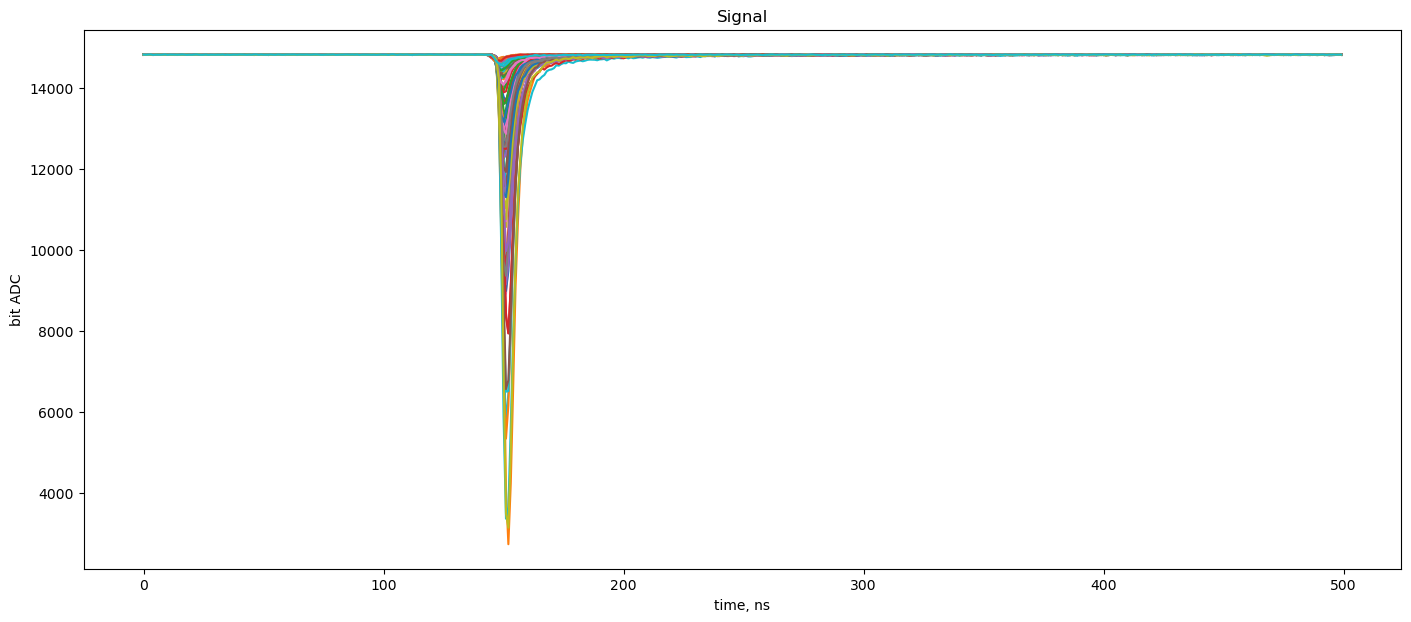

In [13]:
# Вывод 100 случайных сигналов
ax = dataset.T.sample(n=100, axis='columns', random_state=RANDOM_STATE).plot(title='Signal', legend=None, figsize=(17, 7))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")


In [14]:
dataset.describe()

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
count,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,...,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000
mean,14822.972316,14822.958474,14822.970016,14822.989991,14823.003961,14822.978619,14822.968610,14822.954470,14822.963670,14822.968908,...,14822.329017,14822.315686,14822.272073,14822.171728,14822.257123,14822.317092,14822.279399,14822.278163,14822.287789,14822.283743
std,2.805884,2.833516,2.840755,2.852066,2.833412,2.836271,2.831241,2.827526,2.846291,2.814655,...,3.357997,3.373568,3.340707,3.332547,3.290301,3.232245,3.268458,3.251192,3.253340,3.242307
min,14812.000000,14812.000000,14812.000000,14811.000000,14812.000000,14812.000000,14812.000000,14811.000000,14812.000000,14809.000000,...,14800.000000,14798.000000,14802.000000,14796.000000,14802.000000,14801.000000,14798.000000,14804.000000,14800.000000,14802.000000
25%,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,...,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000
50%,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,...,14823.000000,14823.000000,14823.000000,14822.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000
75%,14824.000000,14824.000000,14825.000000,14825.000000,14825.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,...,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000
max,14834.000000,14835.000000,14834.000000,14835.000000,14834.000000,14835.000000,14835.000000,14833.000000,14834.000000,14834.000000,...,14836.000000,14835.000000,14834.000000,14836.000000,14833.000000,14834.000000,14833.000000,14834.000000,14833.000000,14835.000000


In [15]:
dataset.describe().T[['max', 'min']].describe()

,max,min
count,500.000000,500.000000
mean,14833.222000,14526.876000
std,5.180578,1613.825674
min,14758.000000,0.000000
25%,14833.000000,14760.000000
50%,14834.000000,14791.000000
75%,14834.000000,14809.000000
max,14838.000000,14814.000000


**Вывод:** Первоначальные данные представляют собой некий базовый уровень на максимуме (в районе 14835) и узкую яму (сам сигнал) от 0 до 14814.

В бейзлайне указана формула инверсии сигнала: `2**14 - data - 1560`, где 
* `2**14` — разрешение 14-битного АЦП (аналого-цифрового преобразователя);
* `1560` — калибровочное значение этого конкретного датчика в "тихом", ненагруженном состоянии.

In [16]:
# Вывод строк и столбцов, где значение рано нулю
rows_with_zero = (dataset == 0).any(axis=1)
cols_with_zero = (dataset == 0).any(axis=0)

max_outliers = dataset.loc[rows_with_zero, cols_with_zero]
max_outliers

,151,152,153
798,0,0,0
6401,530,0,1032
9190,0,0,1444
9553,1030,0,0
11289,1652,0,311
13595,767,0,0
17790,29,0,72
22310,0,0,2170
23118,0,0,956


Нули в таблице выше — это сигналы настолько сильные, что разрешения прибора не хватает зарегистрировать полную энергию сигнала.

In [17]:
# Инвертируем весь датасет по этой формуле
df = 2**14 - dataset - 1560
df

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,4,1,0,2,6,4,0,2,4,4,...,-4,2,9,9,7,5,4,2,4,5
1,4,2,4,-2,0,2,4,2,1,3,...,-4,7,0,2,0,5,4,5,2,4
2,4,4,2,-1,4,0,0,5,1,0,...,4,3,4,4,6,3,1,4,4,3
3,-4,2,6,0,0,2,4,2,0,4,...,0,-2,2,3,4,-4,4,2,1,2
4,1,9,1,3,-3,4,1,0,8,3,...,4,4,1,-4,0,4,0,0,2,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23474,-2,-3,-1,6,-1,-3,-3,1,1,1,...,-2,-4,-1,5,-2,-4,2,0,0,-3
23475,0,1,5,-4,5,0,0,1,0,3,...,-4,-2,0,10,10,6,8,2,5,7
23476,2,2,0,4,1,-4,1,0,4,0,...,-2,7,9,7,6,7,8,5,7,4
23477,0,1,0,2,3,0,4,2,-4,-3,...,1,0,-3,2,-1,0,2,4,5,0


In [18]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
count,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,...,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000
mean,1.027684,1.041526,1.029984,1.010009,0.996039,1.021381,1.031390,1.045530,1.036330,1.031092,...,1.670983,1.684314,1.727927,1.828272,1.742877,1.682908,1.720601,1.721837,1.712211,1.716257
std,2.805884,2.833516,2.840755,2.852066,2.833412,2.836271,2.831241,2.827526,2.846291,2.814655,...,3.357997,3.373568,3.340707,3.332547,3.290301,3.232245,3.268458,3.251192,3.253340,3.242307
min,-10.000000,-11.000000,-10.000000,-11.000000,-10.000000,-11.000000,-11.000000,-9.000000,-10.000000,-10.000000,...,-12.000000,-11.000000,-10.000000,-12.000000,-9.000000,-10.000000,-9.000000,-10.000000,-9.000000,-11.000000
25%,0.000000,0.000000,-1.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
max,12.000000,12.000000,12.000000,13.000000,12.000000,12.000000,12.000000,13.000000,12.000000,15.000000,...,24.000000,26.000000,22.000000,28.000000,22.000000,23.000000,26.000000,20.000000,24.000000,22.000000


In [19]:
df.describe().T[['max', 'min']].describe()

,max,min
count,500.000000,500.000000
mean,297.124000,-9.222000
std,1613.825674,5.180578
min,10.000000,-14.000000
25%,15.000000,-10.000000
50%,33.000000,-10.000000
75%,64.000000,-9.000000
max,14824.000000,66.000000


Text(0, 0.5, 'bit ADC')

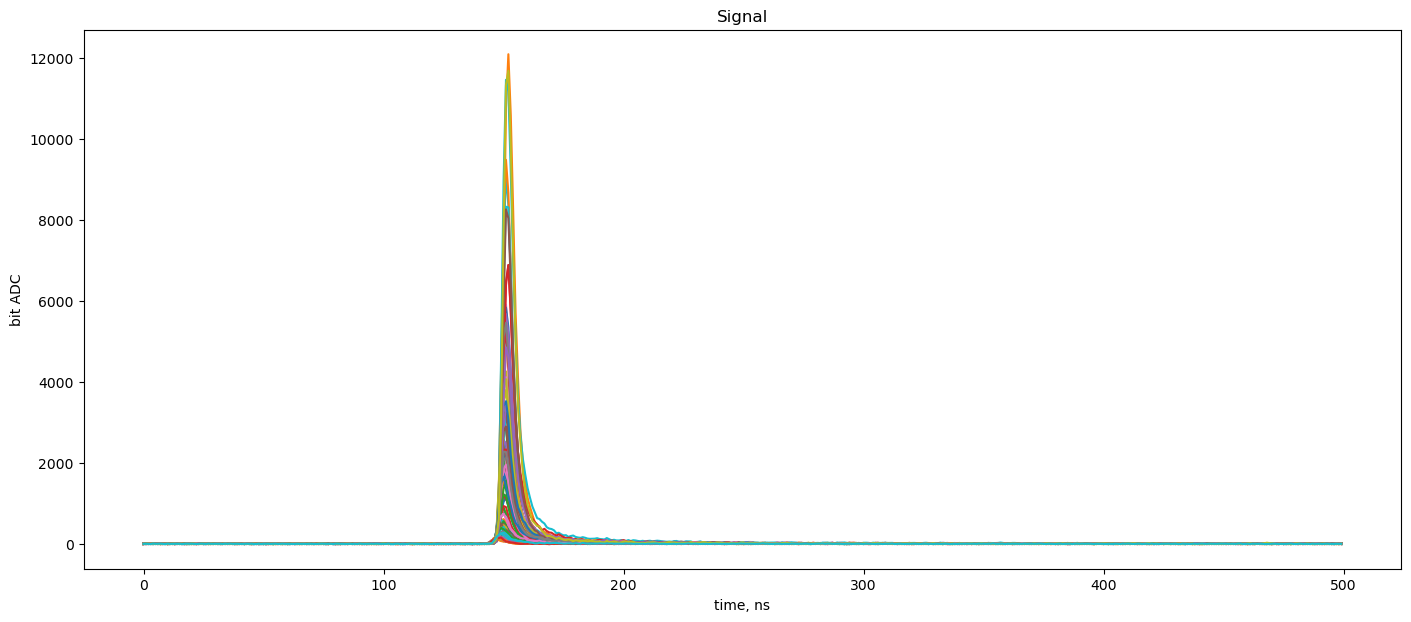

In [20]:
# Вывод 100 случайных сигналов в инверированном виде
ax = df.T.sample(n=100, axis='columns', random_state=RANDOM_STATE).plot(title='Signal', legend=None, figsize=(17, 7))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")


Text(0, 0.5, 'bit ADC')

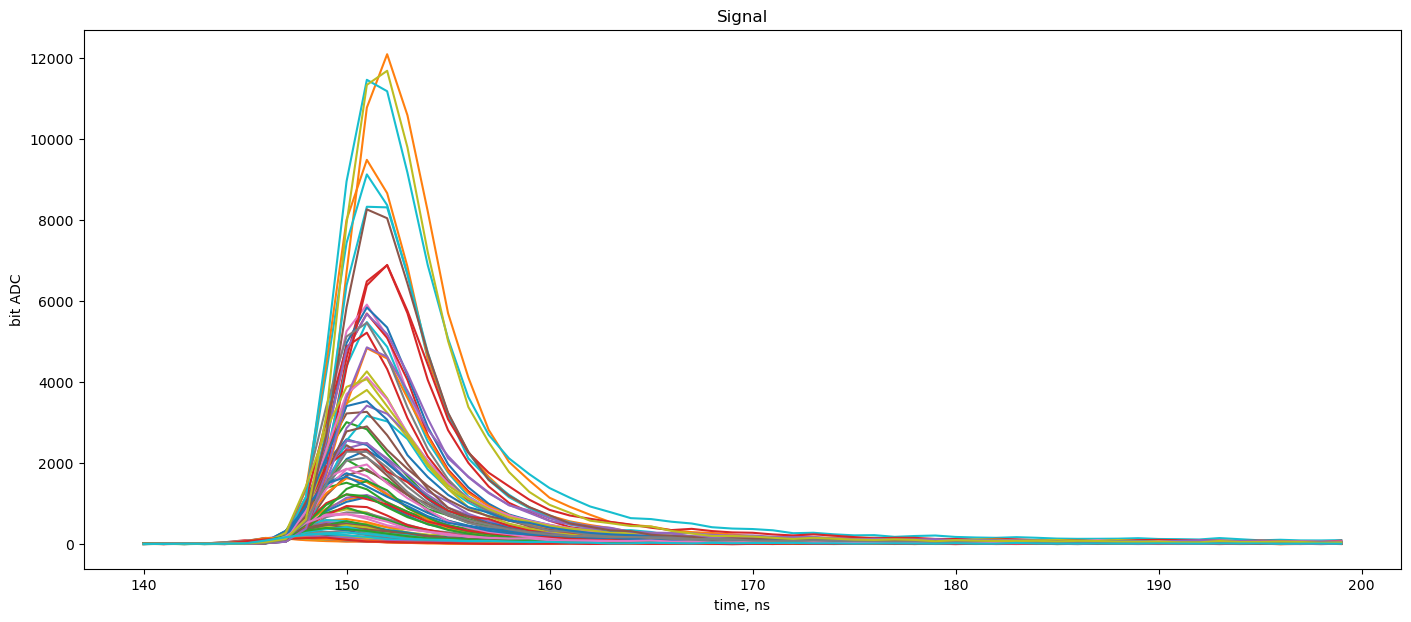

In [21]:
# Вывод 100 случайных сигналов в инверированном виде в районе всплеска
ax = df.T[140:200].sample(n=100, axis='columns', random_state=RANDOM_STATE).plot(title='Signal', legend=None, figsize=(17, 7))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")


Text(0, 0.5, 'bit ADC')

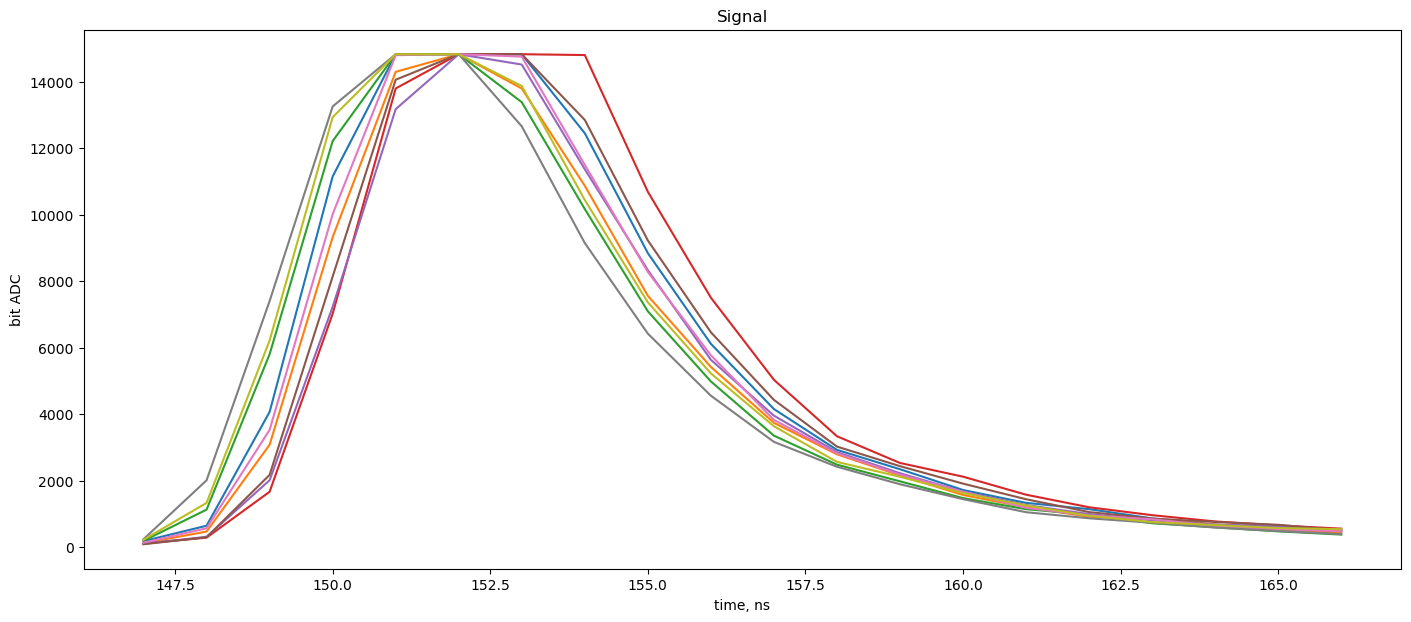

In [22]:
# Вывод сигналов с максимальной амплитудой (обрезанной)
ax = df.T.iloc[147:167, list(max_outliers.index)].plot(title='Signal', legend=None, figsize=(17, 7))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")


**Промежуточный вывод:** Инвертация сигналов прошла успешно, но только теперь стоит учесть, что сигнал может иметь отрицательные характеристики вплоть до $-14$. В целом такая ситуация считается нормальной, некая оссциляция или "шум" около нуля. Потом в вычислениях мы будем оперировать полным сигналом, вычитая базовый уровень и даже если он отрицательный, то показатели площади и амплитуды будут положительными.

**Вывод:** На этом этапе аномалий, выбросов, пропущенных значений и дубликатов не обнаружено. (Есть несколько сигналов с обрезанной верхушкой, максимальное значение нам не известно.)


# 3. Feature Engeneering

Ключевые параметры сигнала:
1. Baseline (Нулевая линия / Шум)
   * Нулевая линия определяется как средний уровень шума до прихода частицы (в левом хвосте кривой).
   * Формула: Вычисляется как среднее арифметическое по первым 50 отсчётам исходного сигнала.
   * Стандартное отклонение шума ($\sigma$): Также рассчитывается по этим же первым 50 отсчётам для определения границ окончания сигнала.
2. Peak (Пик / Амплитуда).
Пик — это максимальное значение сигнала.
3. Rise time (Время нарастания / Фронт импульса). Не используем. "период нарастания не несёт в себе информации, по которой можно было бы отличить одну кривую от другой ввиду того, что процесс нарастания происходит слишком быстро".
4. Tail (Хвост / Зона затухания). 
Именно хвост содержит информацию для разделения (дискриминации) частиц, так как физическая конверсионная эффективность зависит от ионизационных потерь, и сигналы от разных частиц затухают с разной скоростью.
    * Выделение границ сигнала: Сигналом считается подмножество значений от максимума до точки, где сигнал сливается с шумом (отстаёт от нулевой линии на $3σ$).
5. **PSD** (Pulse Shape Discrimination) — главный признак для кластеризации.
    * Для параметризации формы сигнала (разделения гамма/нейтронов) используется отношение площадей:
$$PSD = \frac{long - short}{long}$$
    * long — площадь под всем выделенным сигналом (весь хвост).
    * short — площадь под небольшим фрагментом сигнала в окрестности максимума (в самом начале, где доминирует быстрая компонента).
   * Смысл: Сигналы с более пологой формой (нейтроны) будут иметь значение PSD, стремящееся к 1. Сигналы с острым пиком (гамма-кванты) — меньшее значение.
6. **Tau**. Время затухания сигнала. Используется для разделения частиц на быстрые (гамма) и медленные (нейтроны). В данной работе анализируется только хвост затухания, который начинается, где значение сигнала упало до 40% от максимума. Форма сцинтиляционного хвоста хорошо описывается экспоненциальной функцией:
$$I(t) = A \cdot e^{-t/\tau}$$
Здесь для быстроты используется метод наименьших квадратов через логарифмирование:
$$ln(I(t)) = ln(A) - \frac{t}{\tau}$$
где
    * $I(t)$ — интенсивность сигнала,
    * $A$ — начальная амплитуда,
    * $\tau$ — время высвечивания (искомый параметр).

## Анатомия импульса

Расчет параметров одного сигнала

In [23]:
def plot_scintillation_signal(
    df, signal_idx, left_tail_length=50, n_sigma=3,
):
    """Функция для анализа и визуализации отдельного сигнала сцинтиллятора.

    Параметры:
    - df: инвертированный dataset с сигналами
    - signal_idx: индекс строки/сигнала для анализа
    - left_tail_length: количество первых отсчетов для оценки шума
    - n_sigma: порог чувствительности к шуму (количество сигм)
    """
    
    signal = df.iloc[signal_idx].to_numpy()

    # Нулевая линия = среднее значение левого хвоста
    zero_line = np.mean(signal[:left_tail_length])

    # Стандартное отклонение шума
    noise_std = np.std(signal[:left_tail_length])

    # Находим индекс максимума
    i_max = np.argmax(signal)
    val_max = signal[i_max]
    
    # Ищем конец сигнала: идём от максимума вправо
    signal_end = i_max
    for i in range(i_max, len(signal)):
        if abs(signal[i] - zero_line) <= n_sigma * noise_std:
            signal_end = i
            break

    # Ищем начало сигнала Tau: отступаем до 40% амплитуды
    signal_start = i_max
    threshold = 0.4 * val_max
    for i in range(i_max, len(signal)):
        if abs(signal[i] - zero_line) <= threshold:
            signal_start = i
            break

    # Определяем начало Тау (рядом с максимумом)
    short_length = signal_start - i_max
    short_pos = i_max + short_length

    # Визуализация
    fig, ax = plt.subplots(figsize=(20, 8))

    # Рисуем сигнал
    ax.plot(signal, color="blue", linewidth=1, label="Signal")

    # Нулевая линия (среднее левого хвоста)
    ax.axhline(
        y=zero_line,
        color="green",
        linestyle="--",
        linewidth=2,
        label=f"Zero line (mean={zero_line:.1f})",
    )

    # Границы +-3 sigma от нулевой линии
    ax.axhline(
        y=zero_line + n_sigma * noise_std,
        color="orange",
        linestyle=":",
        linewidth=2,
        label=fr"$+{n_sigma}\sigma$ ({zero_line + n_sigma*noise_std:.1f})",
    )
    ax.axhline(
        y=zero_line - n_sigma * noise_std,
        color="orange",
        linestyle=":",
        linewidth=2,
        label=fr"$-{n_sigma}\sigma$ ({zero_line - n_sigma*noise_std:.1f})",
    )

    # Вертикальная линия максимума
    ax.axvline(
        x=i_max,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Maximum (i={i_max}, val={signal[i_max]:.1f})",
    )

    # Вертикальная линия конца сигнала
    ax.axvline(
        x=signal_end,
        color="purple",
        linestyle="--",
        linewidth=2,
        label=f"Signal end (i={signal_end})",
    )

    # Вертикальная линия начало Тау участка
    ax.axvline(
        x=short_pos,
        color="purple",
        linestyle="--",
        linewidth=1,
        label=fr"Signal $\tau$ position (l={short_length})",
    )

    # Заштриховываем область сигнала
    ax.axvspan(
        i_max, signal_end, alpha=0.2, color="yellow", label="Signal region"
    )

    # Заштриховываем левый хвост (область шума для оценки параметров)
    ax.axvspan(
        0,
        left_tail_length,
        alpha=0.2,
        color="gray",
        label="Left tail (noise estimation)",
    )

    ax.set_xlabel("time, ns")
    ax.set_ylabel("bit ADC")
    ax.set_title(
        f"Signal #{signal_idx} with extracted signal region\n"
        fr"Mean={zero_line:.2f}, $\sigma$={noise_std:.2f}, "
        f"Signal duration: {signal_end - i_max}"
    )

    ax.legend(loc="upper right", fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


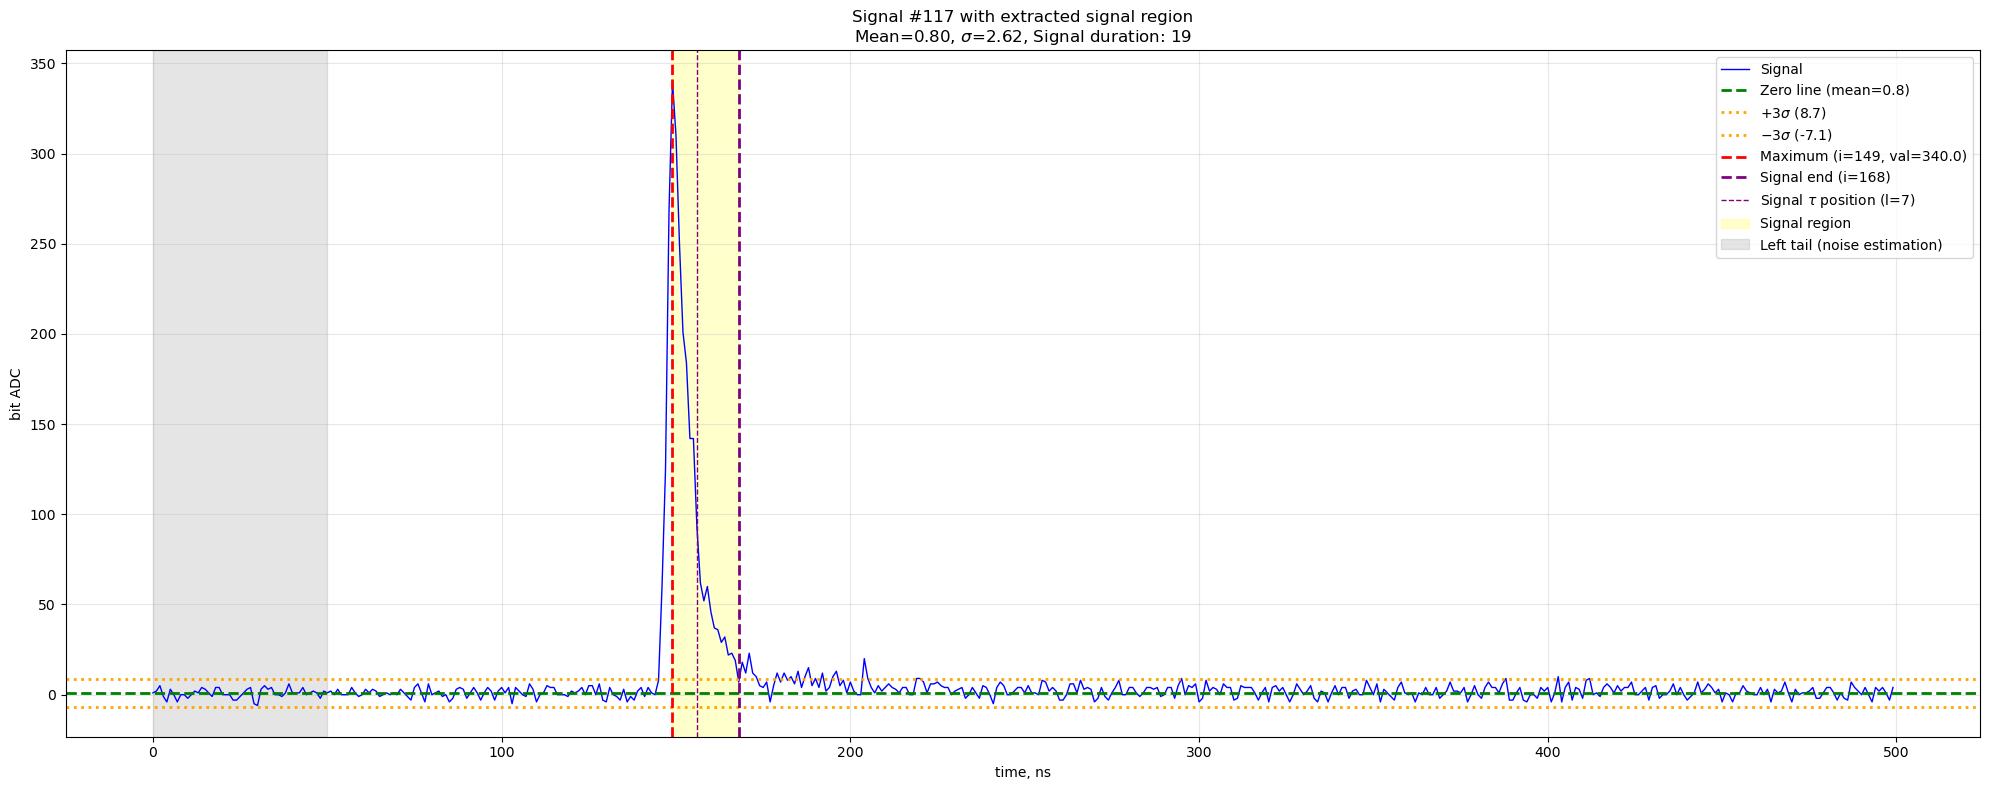

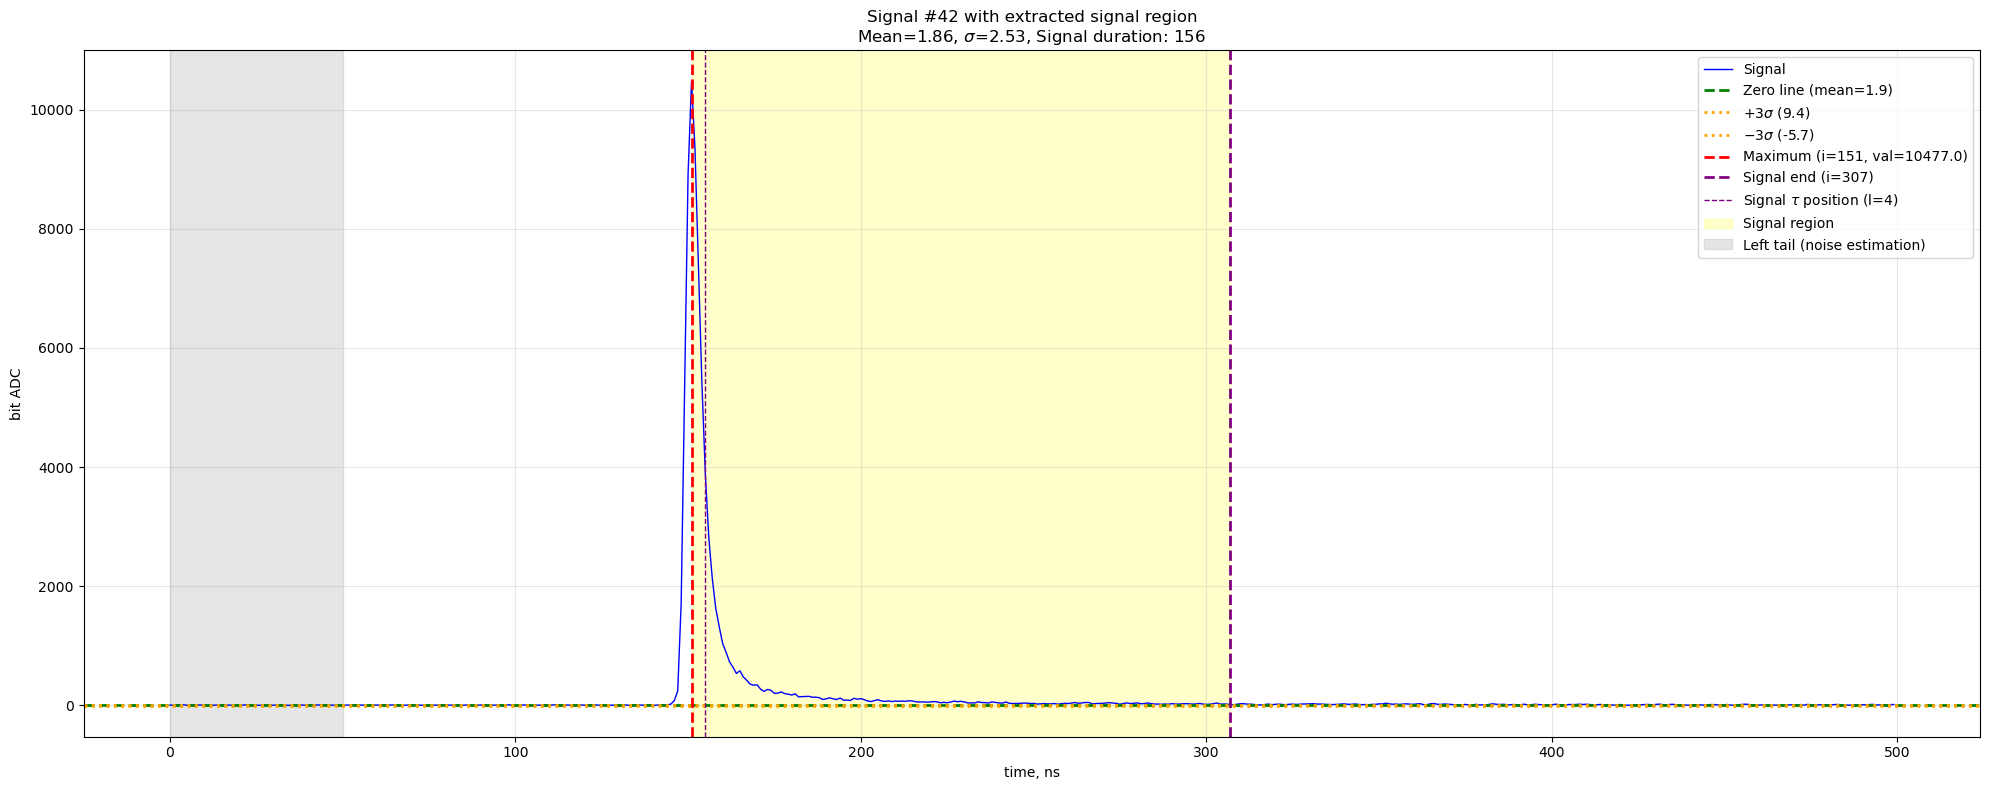

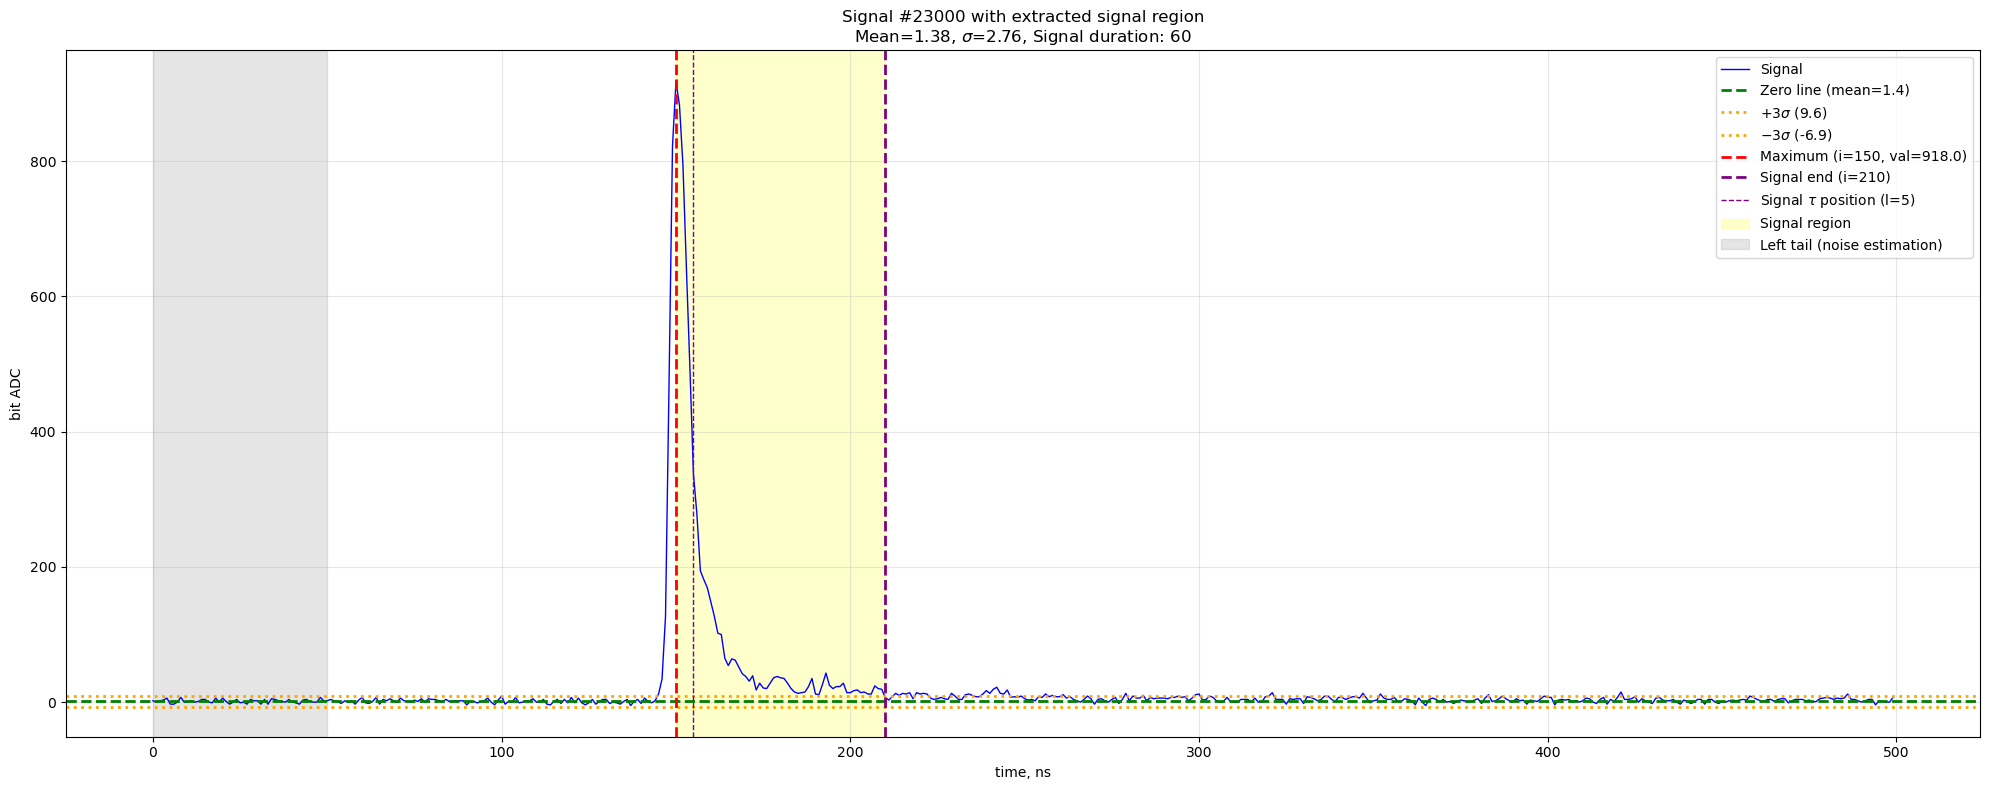

In [24]:
# Посмотреть сигнал под номером 117
plot_scintillation_signal(df, signal_idx=117)

# Посмотреть другой сигнал 42
plot_scintillation_signal(df, signal_idx=42)

# Посмотреть другой сигнал
plot_scintillation_signal(df, signal_idx=23000)


Начало сигнала здесь показано тонкой пунктирной линией, где сигнал достигает значения равного 40% от амплитуды (согласно методичке).

**Промежуточный вывод:** График показывает форму сигнала, от максимального всплеска до уровня, где сигнал возвращается к базовому уровню (плюс три стандартных отклонений от "нулевой линии"). Все три случайно выбранные сигналы имеют разную амплитуду и длину хвоста (время затухания).

## Выделение ключевых параметров для всего датасета

Для определения short участка воспользуемся тем же правилом трёх сигм только в обратном направлении, от максимального всплеска до того участка, где сигнал превысил уровень шума на три стандартных отклонения перед максимумом. Начало сигнала считаем от максимума.

Для сравнения возмём ещё фиксированное значение $3$ такта и ещё одно пропорциональное $15\%$ от всей длины сигнала.

In [25]:
def extract_features(signals_df: pd.DataFrame, left_tail_len=50, n_sigma=3):
    """
    Функция извлечения ключевых признаков.
    Возвращает датафрейм с колонками:
    ['Amplitude', 'Area', 'PSD', 'Tau', 'Signal_Duration']
    """
    # Для ускорения делаем в NumPy
    signals = signals_df.to_numpy()  # (N, 500)
    N, T = signals.shape
    
    # Результирующие массивы
    amplitude = np.empty(N, dtype=np.float32)
    area = np.empty(N, dtype=np.float32)
    psd = np.empty(N, dtype=np.float32)
    tau = np.empty(N, dtype=np.float32)
    duration = np.empty(N, dtype=np.int32)

    for i in tqdm(range(N), desc="Извлечение признаков"):
        signal = signals[i]
        
        # Базовая линия и шум
        baseline = np.mean(signal[:left_tail_len])
        noise_std = np.std(signal[:left_tail_len])
        signal_clean = signal - baseline
        
        # Максимум и границы сигнала
        i_max = np.argmax(signal_clean)
        val_max = signal_clean[i_max]
        
        if val_max <= n_sigma * noise_std:
            # Слишком слабый сигнал — пропускаем
            amplitude[i] = area[i] = psd[i] = tau[i] = duration[i] = np.nan
            print(i, "Слишком слабый сигнал")
            continue
            
        # Конец сигнала: первый отсчёт после максимума, где сигнал смешивается с шумом (шум + сигмы)
        signal_end = i_max
        for j in range(i_max, T):
            if signal_clean[j] <= n_sigma * noise_std:
                signal_end = j
                break
        
        dur = signal_end - i_max
        if dur < 3:  # Слишком короткий
            amplitude[i] = area[i] = psd[i] = tau[i] = duration[i] = np.nan
            print(i, "Слишком короткий сигнал")
            continue
            
        # Полная площадь и амплитуда сигнала
        sig_part = signal_clean[i_max:signal_end]
        total_area = np.sum(sig_part)
        amplitude[i] = val_max
        area[i] = total_area
        duration[i] = dur
        
        # PSD: используем три такта от максимума
        short_len = 3 
        tail_area = np.sum(sig_part[short_len:])
        psd[i] = tail_area / (total_area + 1e-9)
        
        # Tau: отступаем до 40% амплитуды, это хвост, эффективное время затухания
        threshold = 0.4 * val_max
        tail_start_offset = 0
        for k in range(dur):
            if sig_part[k] <= threshold:
                tail_start_offset = k
                break
        
        if tail_start_offset >= dur - 1:
            tau[i] = np.nan
            print(i, 'tail_start_offset >= dur - 1')
            continue
            
        # Берём хвост от точки отступа до конца
        tail = sig_part[tail_start_offset:]
        t = np.arange(len(tail), dtype=np.float32)
        
        # Простая оценка Tau через логарифмирование (без подгонки!)
        mask = tail > 1e-6
        if np.sum(mask) < 2:
            tau[i] = np.nan
            print(i, 'np.sum(mask) < 2')
            continue
            
        log_tail = np.log(tail[mask])
        t_valid = t[mask]
        
        # Линейная регрессия: log(y) = a - t / tau  →  slope = -1/tau
        try:
            # Используем простую формулу для наклона
            n = len(t_valid)
            sum_t = np.sum(t_valid)
            sum_log = np.sum(log_tail)
            sum_t_log = np.sum(t_valid * log_tail)
            sum_t2 = np.sum(t_valid * t_valid)
            
            denom = n * sum_t2 - sum_t * sum_t
            if abs(denom) < 1e-6:
                print(i, 'abs(denom) < 1e-6')
                tau[i] = np.nan
                continue
                
            slope = (n * sum_t_log - sum_t * sum_log) / denom
            if slope >= 0:
                tau[i] = np.nan
                print(i, 'slope >= 0', slope)
                continue
                
            tau_est = -1.0 / slope
            if tau_est < 0.1 or tau_est > 200:
                print(i, 'tau_est < 0.1 or tau_est > 200')
                tau[i] = np.nan
                continue
                
            tau[i] = tau_est
        except:
            print(i, 'except')
            tau[i] = np.nan

    # Создаём датафрейм
    features = pd.DataFrame({
        'Amplitude': amplitude,
        'Area': area,
        'PSD': psd,
        'Tau': tau,
        'Duration': duration
    })
    
    return features

In [26]:
# Запускаем извлечение признаков
df_features = extract_features(df)

Извлечение признаков:  58%|███████████████████████████████                       | 13514/23479 [00:00<00:00, 19606.76it/s]

9577 slope >= 0 0.1513420494815662
10490 slope >= 0 0.01187716398198063


Извлечение признаков: 100%|██████████████████████████████████████████████████████| 23479/23479 [00:01<00:00, 19282.46it/s]


22297 slope >= 0 0.00019761017248790127


Есть исключения, где наклон (slope) больше или равена нулю.

In [27]:
bad_tau = df_features[df_features.isna().any(axis='columns')]
bad_tau

,Amplitude,Area,PSD,Tau,Duration
9577,120.059998,718.719971,0.562862,NaN,12
10490,113.959999,824.479980,0.620512,NaN,13
22297,123.879997,834.599976,0.613420,NaN,20


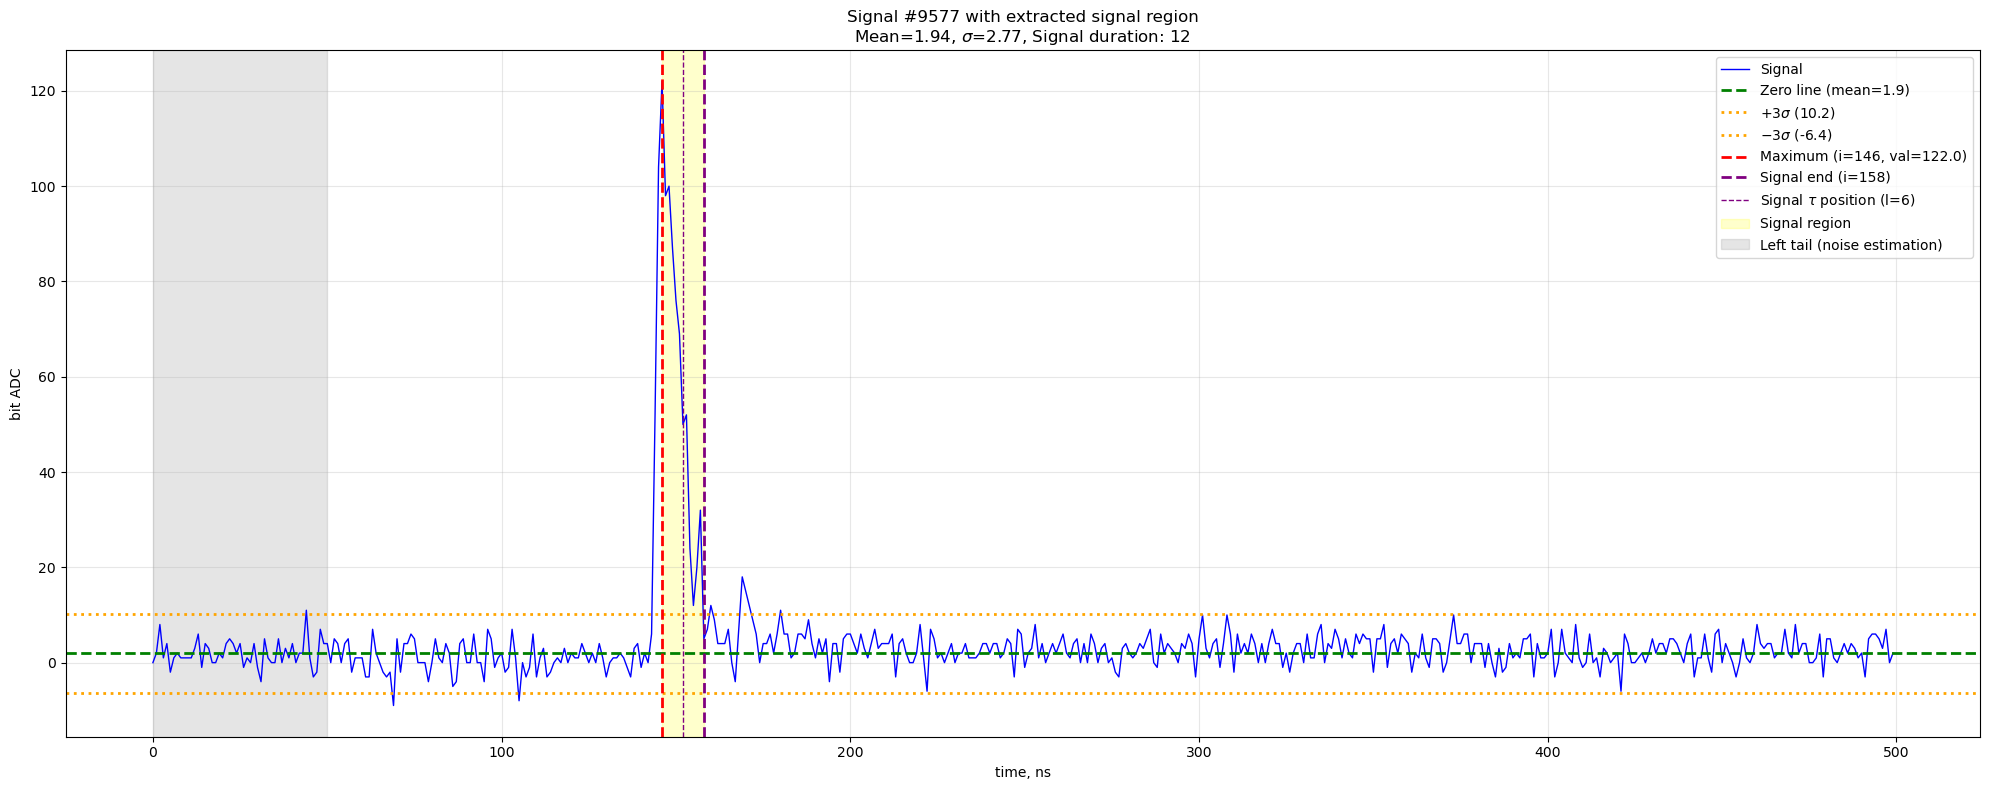

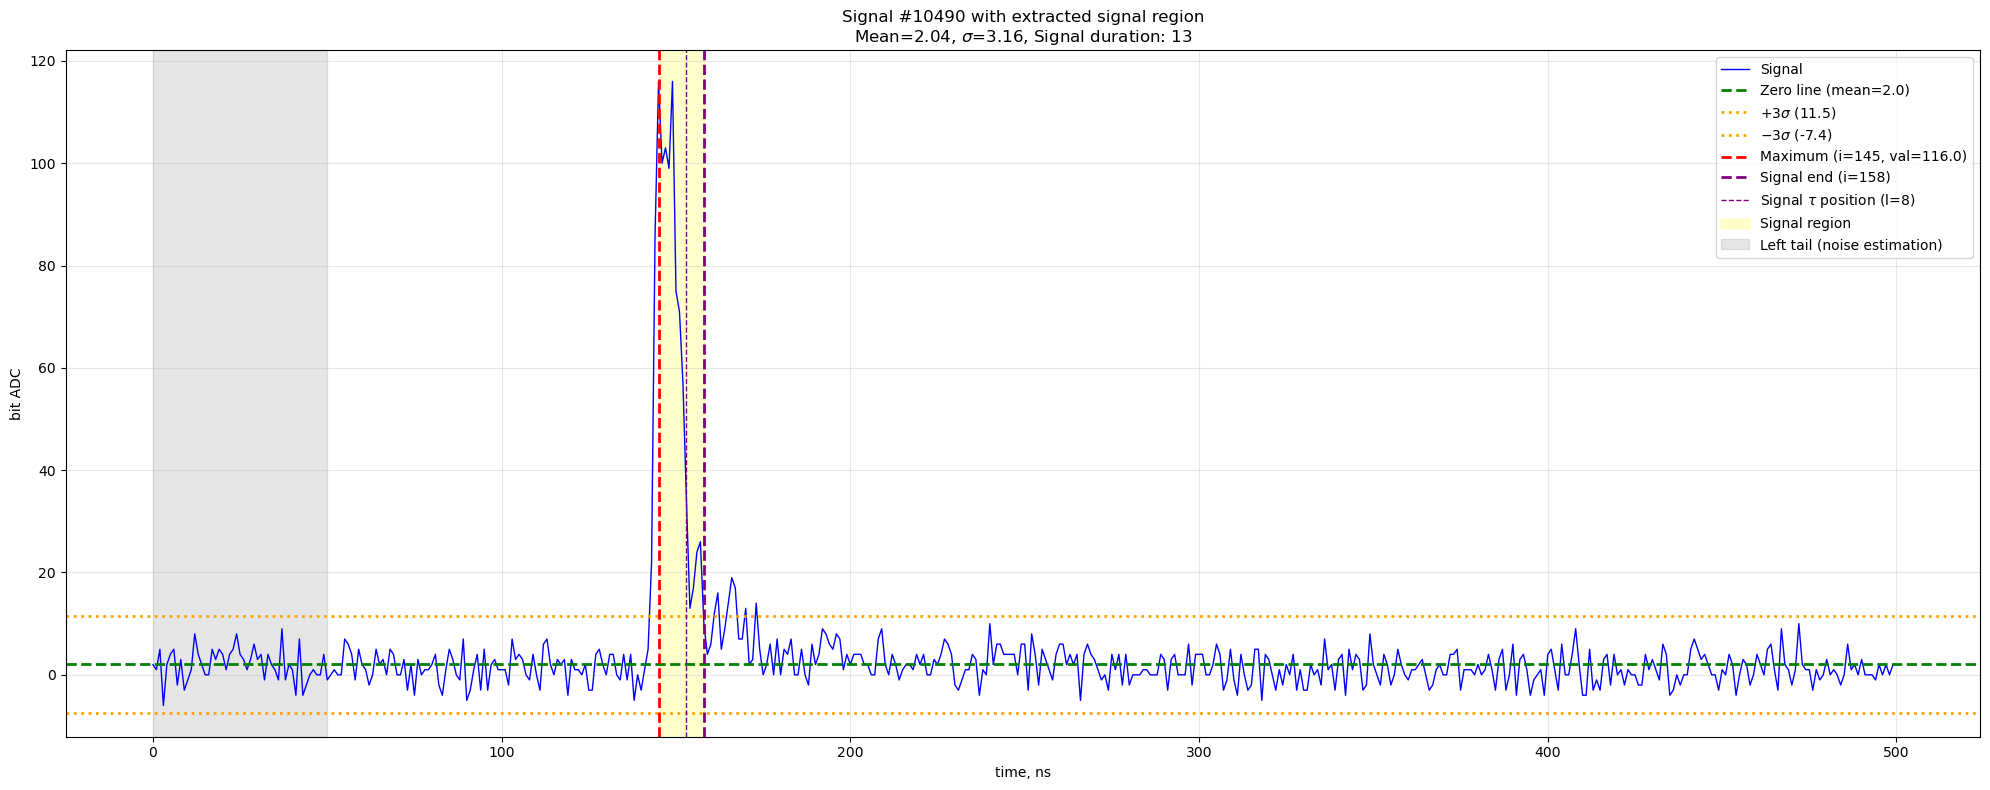

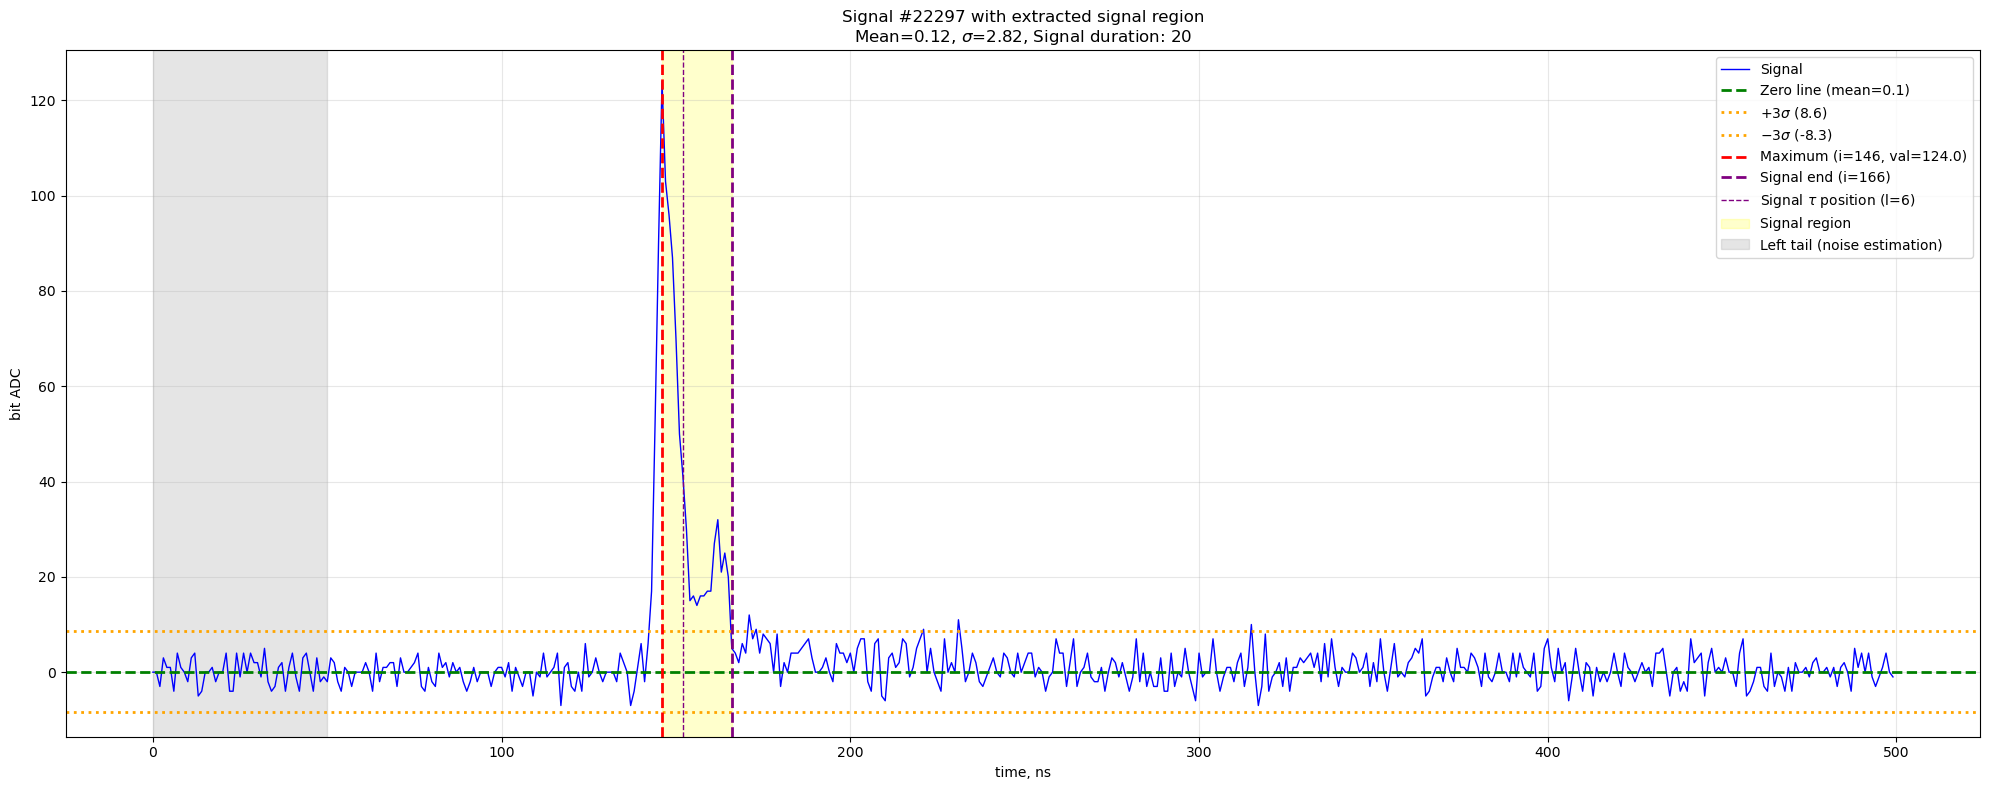

In [28]:
for i in bad_tau.index:
    plot_scintillation_signal(df, signal_idx=i)

На графике у каждого сигнала виден второй всплеск, поэтому затухание по формуле не получилось и пришлось вставить Nan. Заполним эти Тау медианными значениями. Медиана выбрана вместо среднего, так как она устойчива к выбросам, которые могут возникать из-за сбитых сигналов.

In [29]:
# Заполняем NaN в колонке медианой
df_features['Tau'] = df_features['Tau'].fillna(df_features['Tau'].median())


## Анализ полученных данных

In [30]:
df_features.describe().round(2)

,Amplitude,Area,PSD,Tau,Duration
count,23479.00,23479.00,23479.00,23479.00,23479.00
mean,1835.10,9486.62,0.49,11.89,38.99
std,2389.30,12013.95,0.08,8.34,28.97
min,104.30,320.42,0.18,1.40,6.00
25%,308.16,1556.96,0.43,5.49,17.00
50%,812.54,4266.32,0.48,9.32,29.00
75%,2315.05,12520.47,0.57,15.92,53.00
max,14824.84,95463.96,0.68,107.68,216.00


### Матрица кореляций

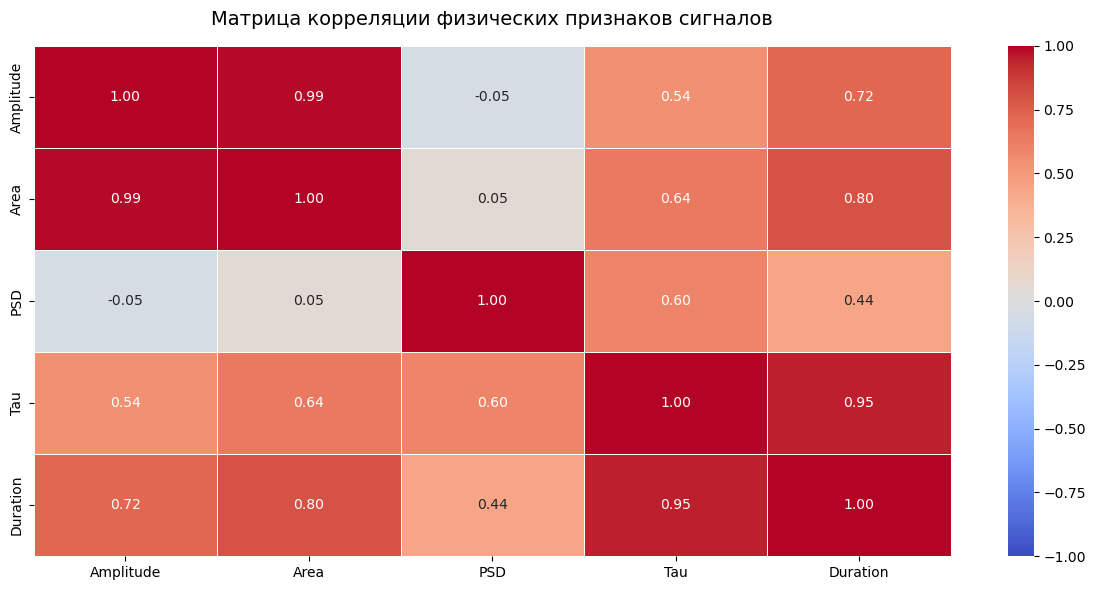

In [31]:
# Вычисляем матрицу корреляции Пирсона
corr_matrix = df_features.corr()

# Настраиваем размер графика
plt.figure(figsize=(12, 6))

# Строим тепловую карту (Heatmap)
sns.heatmap(
    corr_matrix,
    annot=True,  # Выводить коэффициенты внутри ячеек
    cmap="coolwarm",  # Красивая физическая палитра (от синего к красному)
    fmt=".2f",  # Округлять до 2 знаков после запятой
    linewidths=0.5,  # Тонкие границы между ячейками
    vmin=-1,
    vmax=1,  # Границы шкалы корреляции
)

plt.title("Матрица корреляции физических признаков сигналов", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

Ключевой признак — `PSD`. 

Из пары `Tau` и `Duration`, выгодней оставить `Tau`. Он более сложный (отражает затухание сигнала) и меньше коррелирует с `Area` и `Amplitude` и больше с ключевым `PSD`.

Из пары `Area` и `Amplitude`, выгодней оставить `Area`, так как он более сложный, несёт в себе больше информации, высоту и длительность.

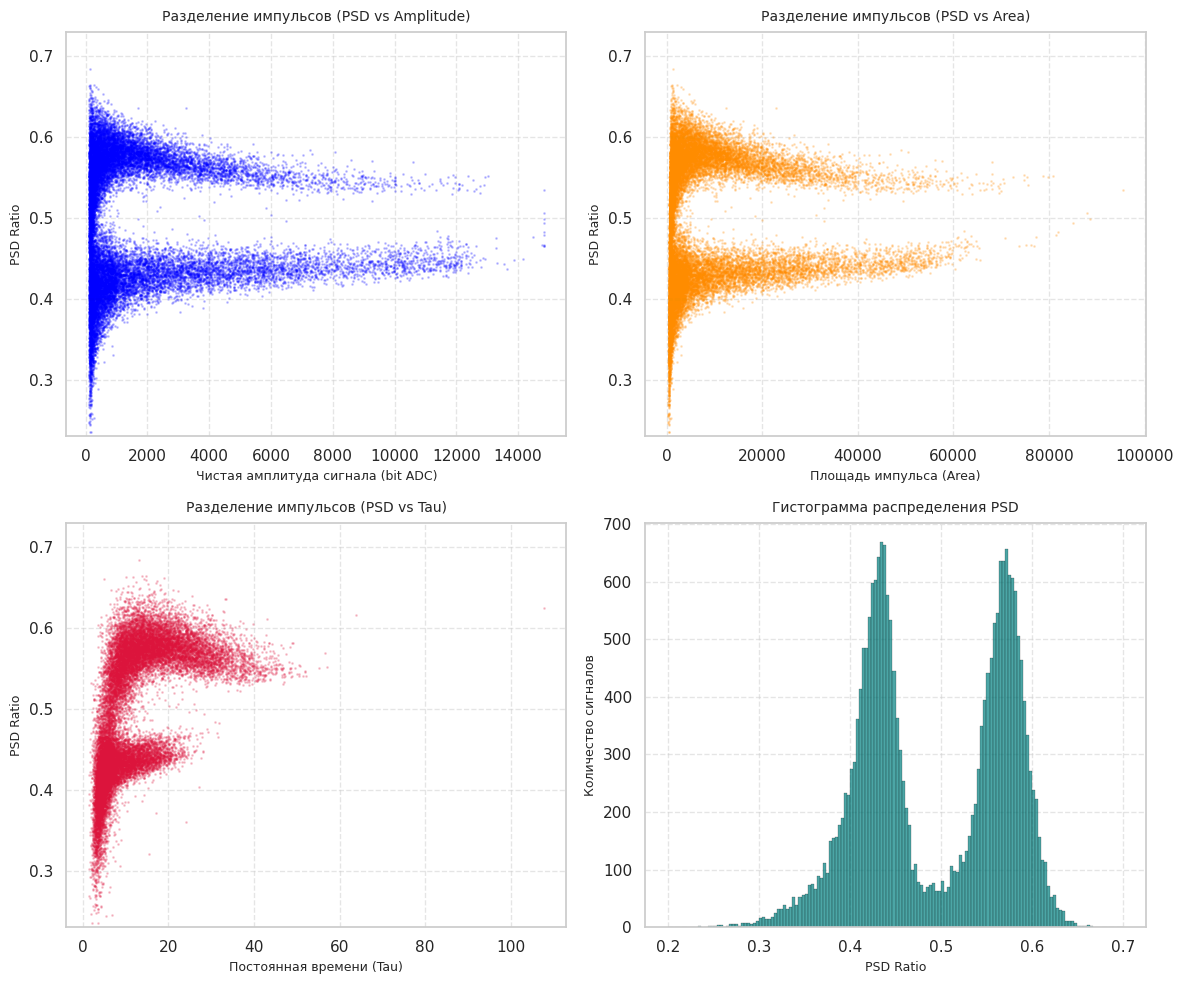

In [32]:
def plot_psd_comprehensive_2x2(df_features, psd='PSD', var1='Amplitude', var2='Area', var3='Tau'):
    # Настраиваем стиль графиков
    sns.set_theme(style="whitegrid")
    # Создаем сетку 2х2 и подбираем сбалансированный размер окна
    fig, ax = plt.subplots(2, 2, figsize=(12, 10)) 
    
    # --- СТРОКА 1, КОЛОНКА 1: Scatter Plot (PSD vs Amplitude) ---
    ax[0, 0].scatter(df_features[var1], df_features[psd], s=1, alpha=0.2, color='blue')
    ax[0, 0].set_title(f'Разделение импульсов ({psd} vs {var1})', fontsize=10, pad=8)
    ax[0, 0].set_xlabel('Чистая амплитуда сигнала (bit ADC)', fontsize=9)
    ax[0, 0].set_ylabel('PSD Ratio', fontsize=9)
    ax[0, 0].set_ylim(0.23, 0.73)
    ax[0, 0].grid(True, linestyle='--', alpha=0.5)
    
    # --- СТРОКА 1, КОЛОНКА 2: Scatter Plot (PSD vs Area) ---
    ax[0, 1].scatter(df_features[var2], df_features[psd], s=1, alpha=0.2, color='darkorange')
    ax[0, 1].set_title(f'Разделение импульсов ({psd} vs {var2})', fontsize=10, pad=8)
    ax[0, 1].set_xlabel('Площадь импульса (Area)', fontsize=9)
    ax[0, 1].set_ylabel('PSD Ratio', fontsize=9)
    ax[0, 1].set_ylim(0.23, 0.73)
    ax[0, 1].grid(True, linestyle='--', alpha=0.5)
    
    # --- СТРОКА 2, КОЛОНКА 1: Scatter Plot (PSD vs Tau) ---
    ax[1, 0].scatter(df_features[var3], df_features[psd], s=1, alpha=0.2, color='crimson')
    ax[1, 0].set_title(f'Разделение импульсов ({psd} vs {var3})', fontsize=10, pad=8)
    ax[1, 0].set_xlabel('Постоянная времени (Tau)', fontsize=9)
    ax[1, 0].set_ylabel('PSD Ratio', fontsize=9)
    ax[1, 0].set_ylim(0.23, 0.73)
    ax[1, 0].grid(True, linestyle='--', alpha=0.5)
    
    # --- СТРОКА 2, КОЛОНКА 2: Гистограмма распределения параметра PSD ---
    ax[1, 1].hist(df_features[psd], bins=150, range=(0.2, 0.7), color='teal', alpha=0.7, edgecolor='black', linewidth=0.2)
    ax[1, 1].set_title('Гистограмма распределения PSD', fontsize=10, pad=8)
    ax[1, 1].set_xlabel('PSD Ratio', fontsize=9)
    ax[1, 1].set_ylabel('Количество сигналов', fontsize=9)
    ax[1, 1].grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

# Вызов функции
plot_psd_comprehensive_2x2(df_features, 'PSD')


Из графиков видно, что Площадь сигнала и PSD, примерно также разделяют сигналы на две чёткие категории, как и с Амплитудой из методики. Что тоже соответсвует предыдущему выводу, что можно оставить только Area.

In [33]:
# Удаление избыточных признаков
cols_to_drop = ['Amplitude', 'Duration',]
df_features = df_features.drop(cols_to_drop, axis='columns')

## Обработка выбросов и логарифмирование

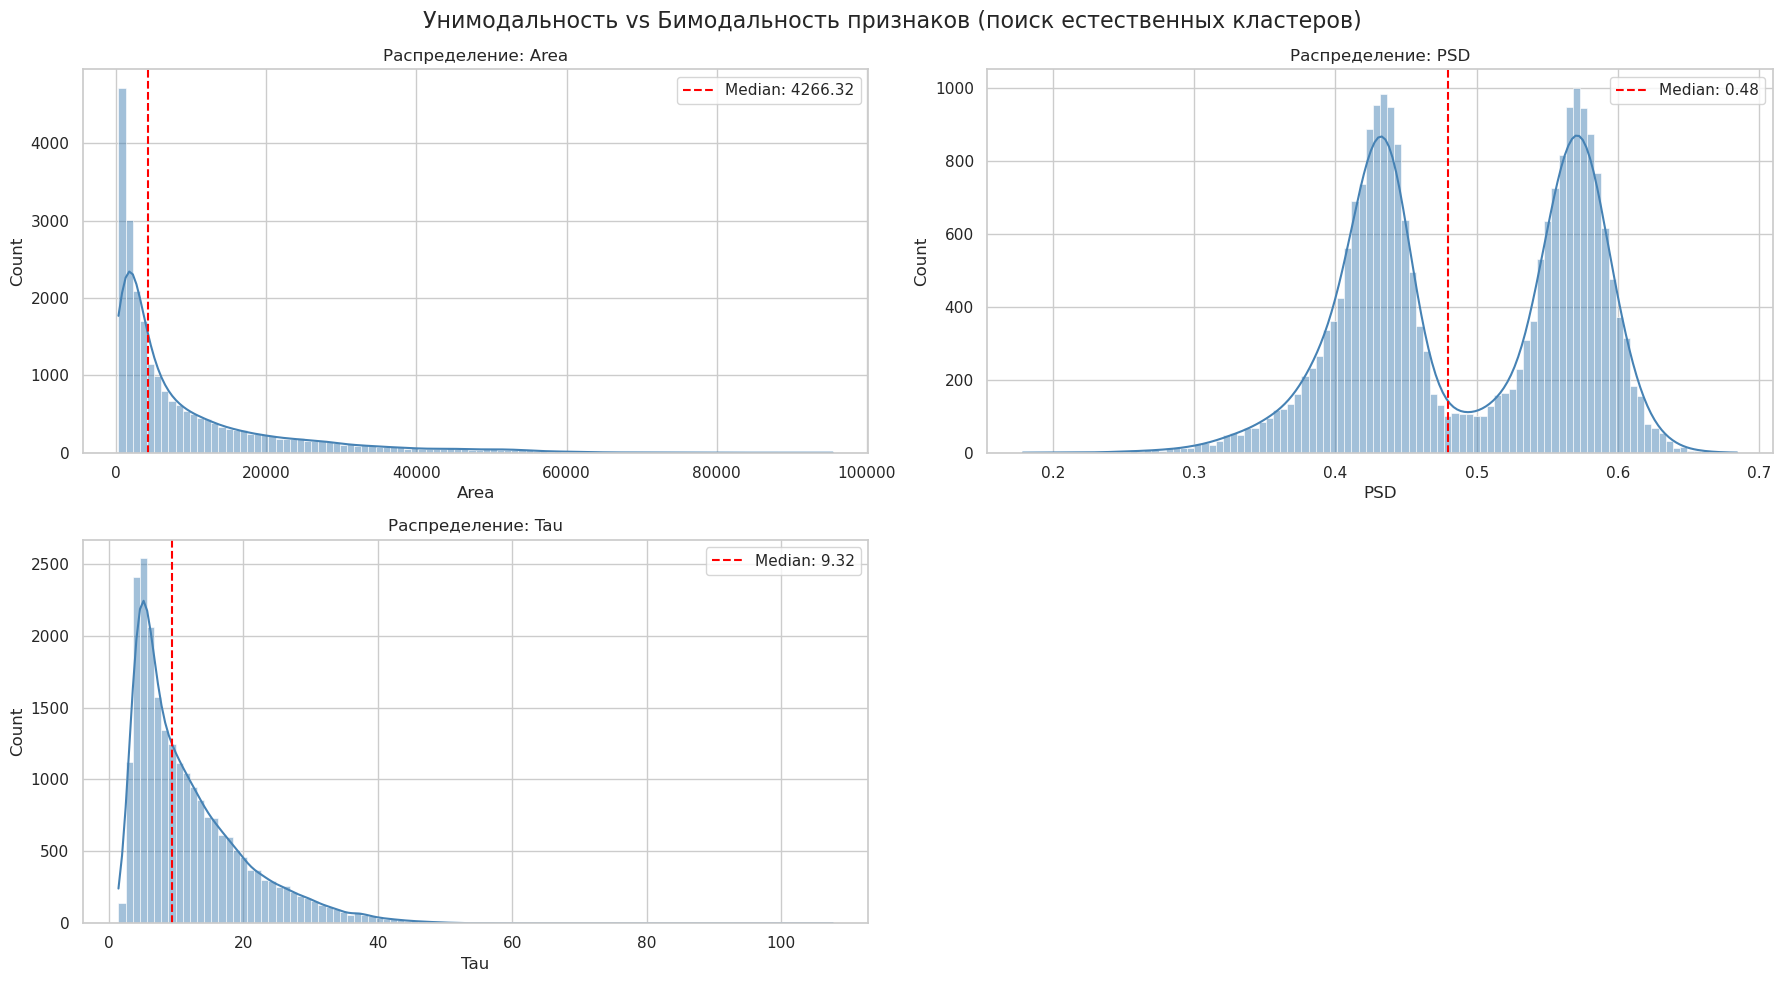

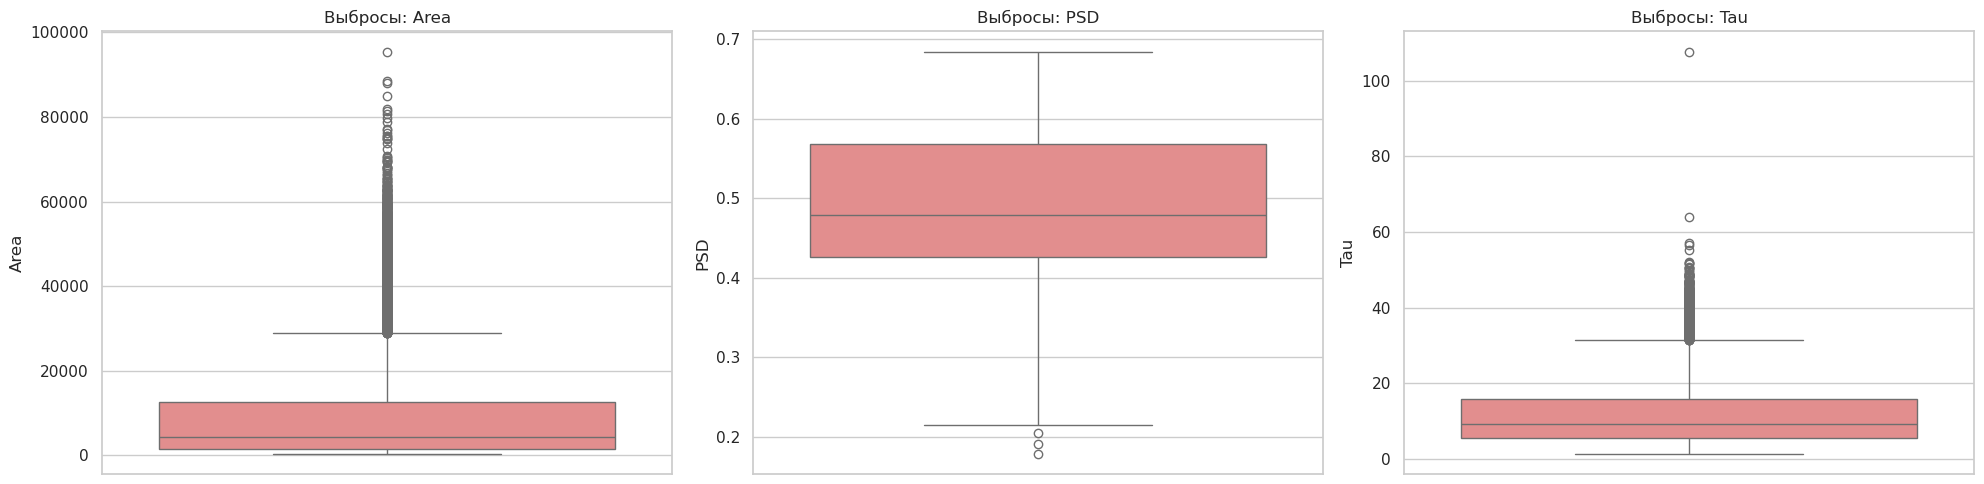

In [34]:
def plot_feature_analysis(df, feature_cols, figsize_hist=(18, 10), figsize_box=(20, 5)):
    """
    Визуализирует распределение признаков (гистограммы с KDE) и ящики с усами (boxplot).
    
    Parameters:
    df (pd.DataFrame): Исходный датафрейм с данными.
    feature_cols (list): Список названий колонок для анализа.
    figsize_hist (tuple): Размер фигуры для гистограмм.
    figsize_box (tuple): Размер фигуры для boxplot.
    """
    num_features = len(feature_cols)
    if num_features == 0:
        print("Список признаков пуст.")
        return

    # --- 1. Анализ распределений (Гистограммы) ---
    # Вычисляем размер сетки (минимум 2 колонки для красивого отображения)
    n_cols_hist = 2
    n_rows_hist = math.ceil(num_features / n_cols_hist)
    
    fig, axes = plt.subplots(n_rows_hist, n_cols_hist, figsize=figsize_hist)
    
    # Делаем axes плоским массивом для удобства итерации (даже если сетка 1х1 или 1х2)
    axes_flat = axes.flatten() if num_features > 1 else [axes]

    for i, col in enumerate(feature_cols):
        ax = axes_flat[i]
        median_val = df[col].median()
        
        sns.histplot(df[col], bins=100, kde=True, ax=ax, color='steelblue')
        ax.axvline(median_val, color='red', linestyle='--', label=f'Median: {median_val:.2f}')
        ax.set_title(f'Распределение: {col}')
        ax.legend()

    # Скрываем неиспользованные оси, если количество признаков не заполняет сетку полностью
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')     

    plt.suptitle('Унимодальность vs Бимодальность признаков (поиск естественных кластеров)', fontsize=16)
    plt.tight_layout()
    plt.show()

    # --- 2. Выявление выбросов (Box-plots) ---
    fig, axes_box = plt.subplots(1, num_features, figsize=figsize_box)
    
    # Гарантируем, что axes_box является итерируемым, даже если признак всего один
    if num_features == 1:
        axes_box = [axes_box]
        
    for i, col in enumerate(feature_cols):
        sns.boxplot(y=df[col], ax=axes_box[i], color='lightcoral')
        axes_box[i].set_title(f'Выбросы: {col}')
        
    plt.tight_layout()
    plt.show()

# Вызов функции
feature_cols = ['Area', 'PSD', 'Tau']
plot_feature_analysis(df_features, feature_cols)

Анализ распределений показывает бимодальность признака `psd`, что указывает на наличие двух естественных кластеров (гамма-кванты и нейтроны). 

Признаки Area и Tau имеют сильную правостороннею ассиметрию, это говорит о том, что мы имеем дело с логарифмическим распределением и лучше прологарифмировать эти признаки.

In [35]:
df_features.describe()

,Area,PSD,Tau
count,23479.000000,23479.000000,23479.000000
mean,9486.624023,0.492627,11.886038
std,12013.951172,0.079914,8.337379
min,320.420013,0.178627,1.403500
25%,1556.959961,0.426280,5.493849
50%,4266.319824,0.479484,9.317282
75%,12520.470215,0.568564,15.917752
max,95463.960938,0.684376,107.678955


In [36]:
# Логарифмирование
df_features['Area'] = np.log(df_features['Area'])
df_features['Tau'] = np.log(df_features['Tau'])

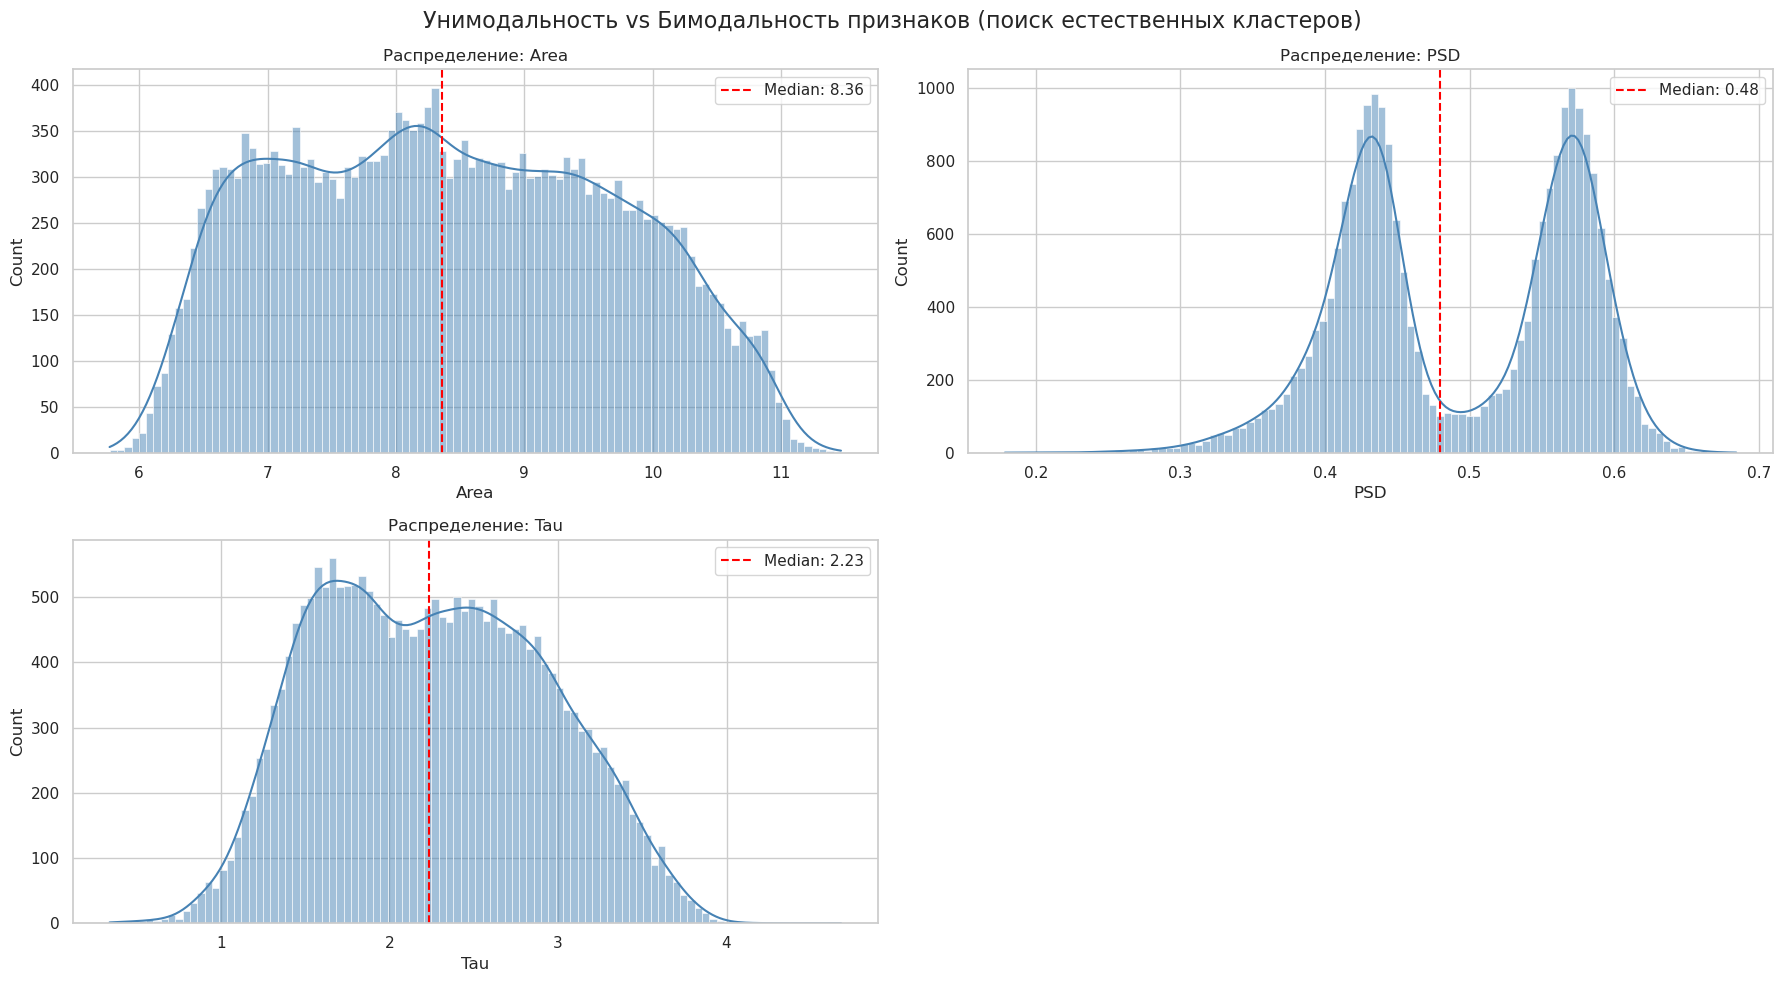

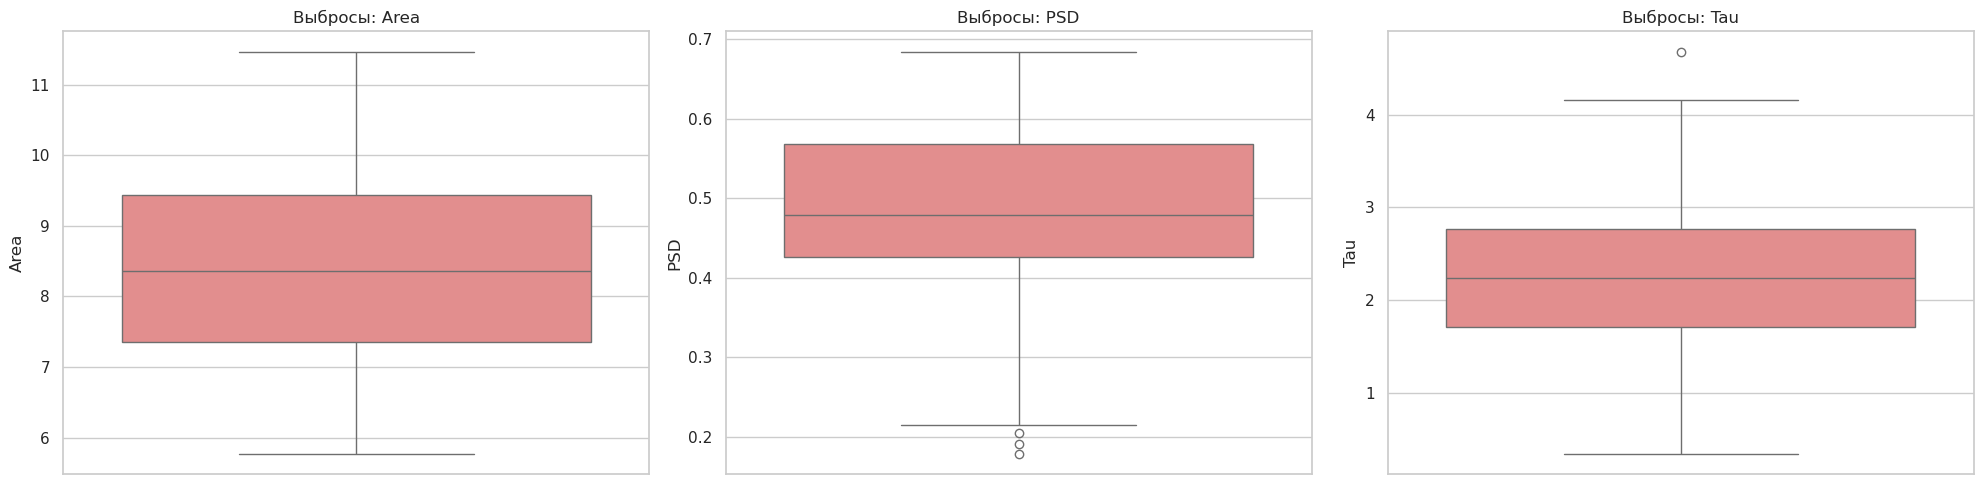

In [37]:
# Выведем график ещё раз после логарифмирования
plot_feature_analysis(df_features, ['Area', 'PSD', 'Tau'])

In [38]:
# Обработка выбросов через IQR (сохраняем "аномалии" для будущего 3-го кластера)
df_features['is_outlier'] = False
for col in feature_cols:
    Q1 = df_features[col].quantile(0.25)
    Q3 = df_features[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_features['is_outlier'] |= (df_features[col] < lower) | (df_features[col] > upper)

print(f"Доля выбросов: {df_features['is_outlier'].mean():.2%}")
print(f"Количество выбросов: {df_features['is_outlier'].sum()}")

df_outliers = df_features['is_outlier'].copy()
df_features = df_features.drop(columns=['is_outlier'])

Доля выбросов: 0.02%
Количество выбросов: 4


**Вывод:** Видно, что после логарифмирования распределения нормализовались, а количество выбросов уменьшилось. Даже можно сказать, что появились намёки на бимодальность в распределениях.

# 4. Clustering

## Готовим данные для кластеризации


In [39]:
# Подготовка признаков

# Выбираем признаки 
features_for_clustering = ['Area', 'PSD', 'Tau']

X_raw = df_features[features_for_clustering].to_numpy()

# RobustScaler устойчив к выбросам (важно для 3-го кластера аномалий!)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_raw)

# PCA для визуализации и снижения шума
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f"Объяснённая дисперсия: PC1={pca.explained_variance_ratio_[0]:.0%}, PC2={pca.explained_variance_ratio_[1]:.0%}")

# Сохраняем в DataFrame
df_clustering = pd.DataFrame(X_scaled, columns=features_for_clustering)
df_clustering['PC1'] = X_pca[:, 0]
df_clustering['PC2'] = X_pca[:, 1]

Объяснённая дисперсия: PC1=71%, PC2=25%


## Пайплайн с 5 моделями и подбором гиперпараметров


In [40]:
def evaluate_clustering(X, labels):
    """Универсальная функция оценки качества кластеризации"""
    unique_labels = len(set(labels)) - (1 if -1 in labels else 0)
    if unique_labels < 2:
        return {'silhouette': np.nan, 'calinski': np.nan, 'davies': np.nan}
    
    # Для DBSCAN с шумом берём только точки, отнесённые к кластерам
    mask = labels != -1
    if mask.sum() < 2:
        return {'silhouette': np.nan, 'calinski': np.nan, 'davies': np.nan}
    
    return {
        'silhouette': silhouette_score(X[mask], labels[mask]),
        'calinski': calinski_harabasz_score(X[mask], labels[mask]),
        'davies': davies_bouldin_score(X[mask], labels[mask]),
    }

In [41]:
# Конфигурация моделей с сетками гиперпараметров
MODELS_CONFIG = {
    'KMeans': {
        'class': KMeans,
        'params': {
            'n_clusters': [2, 3, 4],
            'init': ['k-means++', 'random'],
            'n_init': [10, 20],
            'random_state': [RANDOM_STATE],
        }
    },
    'GaussianMixture': {
        'class': GaussianMixture,
        'params': {
            'n_components': [2, 3, 4],
            'covariance_type': ['full', 'tied', 'diag'],
            'random_state': [RANDOM_STATE],
        }
    },
    'Agglomerative': {
        'class': AgglomerativeClustering,
        'params': {
            'n_clusters': [2, 3, 4],
            'linkage': ['ward', 'complete', 'average'],
        }
    },
    'DBSCAN': {
        'class': DBSCAN,
        'params': {
            'eps': [0.15, 0.2, 0.3, 0.4],
            'min_samples': [30, 60],
        }
    },
    'HDBSCAN': {
        # Передаем сам класс из библиотеки hdbscan
        'class': hdbscan.HDBSCAN, 
        'params': {
            'cluster_selection_method': ['leaf'],            
            'min_cluster_size': [300, 500, 800],
            'min_samples': [15, 30, 60],
            'metric': ['euclidean']
        }
    },
    # Отключен, очень долго считает O(N^3)
    # 'SpectralClustering': {
    #     'class': SpectralClustering,
    #     'params': {
    #         'n_clusters': [2, 3, 4],
    #         'affinity': ['rbf', 'nearest_neighbors'],
    #         'random_state': [42],
    #     }
    # },
}

In [42]:
def run_clustering_pipeline(X, config_dict, target_clusters=2):
    """
    Запускает Grid Search. Метрики для моделей с шумом считаются ТОЛЬКО по чистым кластерам.
    target_clusters = 2 (так как шум -1 выносится за скобки)
    """
    results = []
    best_models = {}
    
    for model_name, cfg in config_dict.items():
        print(f"\n🔍 Обучение: {model_name}")
        print("-" * 50)
        
        best_score = -np.inf
        best_params = None
        best_labels = None
        best_model = None 
        
        grid = ParameterGrid(cfg['params'])
        
        for params in tqdm(grid, desc=f"  {model_name}"):
            try:
                model = cfg['class'](**params)
                
                if hasattr(model, 'fit_predict'):
                    labels = model.fit_predict(X)
                else:
                    model.fit(X)
                    labels = model.predict(X) if hasattr(model, 'predict') else model.labels_
                
                # Для расчета метрик фильтруем шум
                is_noise = (labels == -1)
                n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
                
                # Если все точки ушли в шум или остался 0-1 кластер, модель невалидна
                if n_clusters < 2 or np.all(is_noise):
                    continue
                
                # Считаем метрики качества ТОЛЬКО для реальных кластеров (без шума)
                X_clean = X[~is_noise]
                labels_clean = labels[~is_noise]
                
                metrics = evaluate_clustering(X_clean, labels_clean)
                
                # Штрафуем за отклонение от 2 физических кластеров (нейтроны и гамма)
                cluster_penalty = abs(n_clusters - target_clusters) * 100
                score = metrics['calinski'] - cluster_penalty if not np.isnan(metrics['calinski']) else -np.inf
                
                if score > best_score:
                    best_score = score
                    best_params = params
                    best_labels = labels
                    best_model = model
                    
            except Exception as e:
                continue
        
        if best_labels is not None:
            # Для финального отчета также считаем метрики на «чистых» данных
            is_noise = (best_labels == -1)
            X_clean = X[~is_noise]
            labels_clean = best_labels[~is_noise]
            
            best_metrics = evaluate_clustering(X_clean, labels_clean)
            n_clusters = len(set(best_labels)) - (1 if -1 in best_labels else 0)
            
            results.append({
                'Model': model_name,
                'Best_Params': str(best_params),
                'n_clusters': n_clusters,
                'Has_Noise_Class': int(np.any(is_noise)), # Индикатор: нашел ли алгоритм аномалии
                'Silhouette': best_metrics['silhouette'],
                'Calinski-Harabasz': best_metrics['calinski'],
                'Davies-Bouldin': best_metrics['davies']
            })
            best_models[model_name] = best_model
            
            print(f"  ✅ Лучший Calinski (без шума): {best_metrics['calinski']:.2f}")
            print(f"  ✅ Silhouette (без шума): {best_metrics['silhouette']:.4f}")
            print(f"  ✅ Физических кластеров: {n_clusters} (Шум обнаружен: {np.any(is_noise)})")
            
    return pd.DataFrame(results), best_models

# ЗАПУСК (теперь ищем 2 физических кластера, а шум отбросится автоматически)
results_df, trained_models = run_clustering_pipeline(X_scaled, MODELS_CONFIG, target_clusters=2)



🔍 Обучение: KMeans
--------------------------------------------------


  KMeans: 100%|███████████████████████████████████████████████████████████████████████████| 12/12 [01:25<00:00,  7.10s/it]


  ✅ Лучший Calinski (без шума): 27897.07
  ✅ Silhouette (без шума): 0.4616
  ✅ Физических кластеров: 4 (Шум обнаружен: False)

🔍 Обучение: GaussianMixture
--------------------------------------------------


  GaussianMixture: 100%|████████████████████████████████████████████████████████████████████| 9/9 [01:04<00:00,  7.18s/it]


  ✅ Лучший Calinski (без шума): 27394.04
  ✅ Silhouette (без шума): 0.4570
  ✅ Физических кластеров: 4 (Шум обнаружен: False)

🔍 Обучение: Agglomerative
--------------------------------------------------


...

  ✅ Лучший Calinski (без шума): 21272.52
  ✅ Silhouette (без шума): 0.3902
  ✅ Физических кластеров: 3 (Шум обнаружен: False)

🔍 Обучение: DBSCAN
--------------------------------------------------


  DBSCAN: 100%|█████████████████████████████████████████████████████████████████████████████| 8/8 [00:05<00:00,  1.36it/s]



🔍 Обучение: HDBSCAN
--------------------------------------------------


  HDBSCAN: 100%|████████████████████████████████████████████████████████████████████████████| 9/9 [00:30<00:00,  3.36s/it]


  ✅ Лучший Calinski (без шума): 14703.56
  ✅ Silhouette (без шума): 0.3870
  ✅ Физических кластеров: 2 (Шум обнаружен: True)


## Визуализация результатов всех моделей


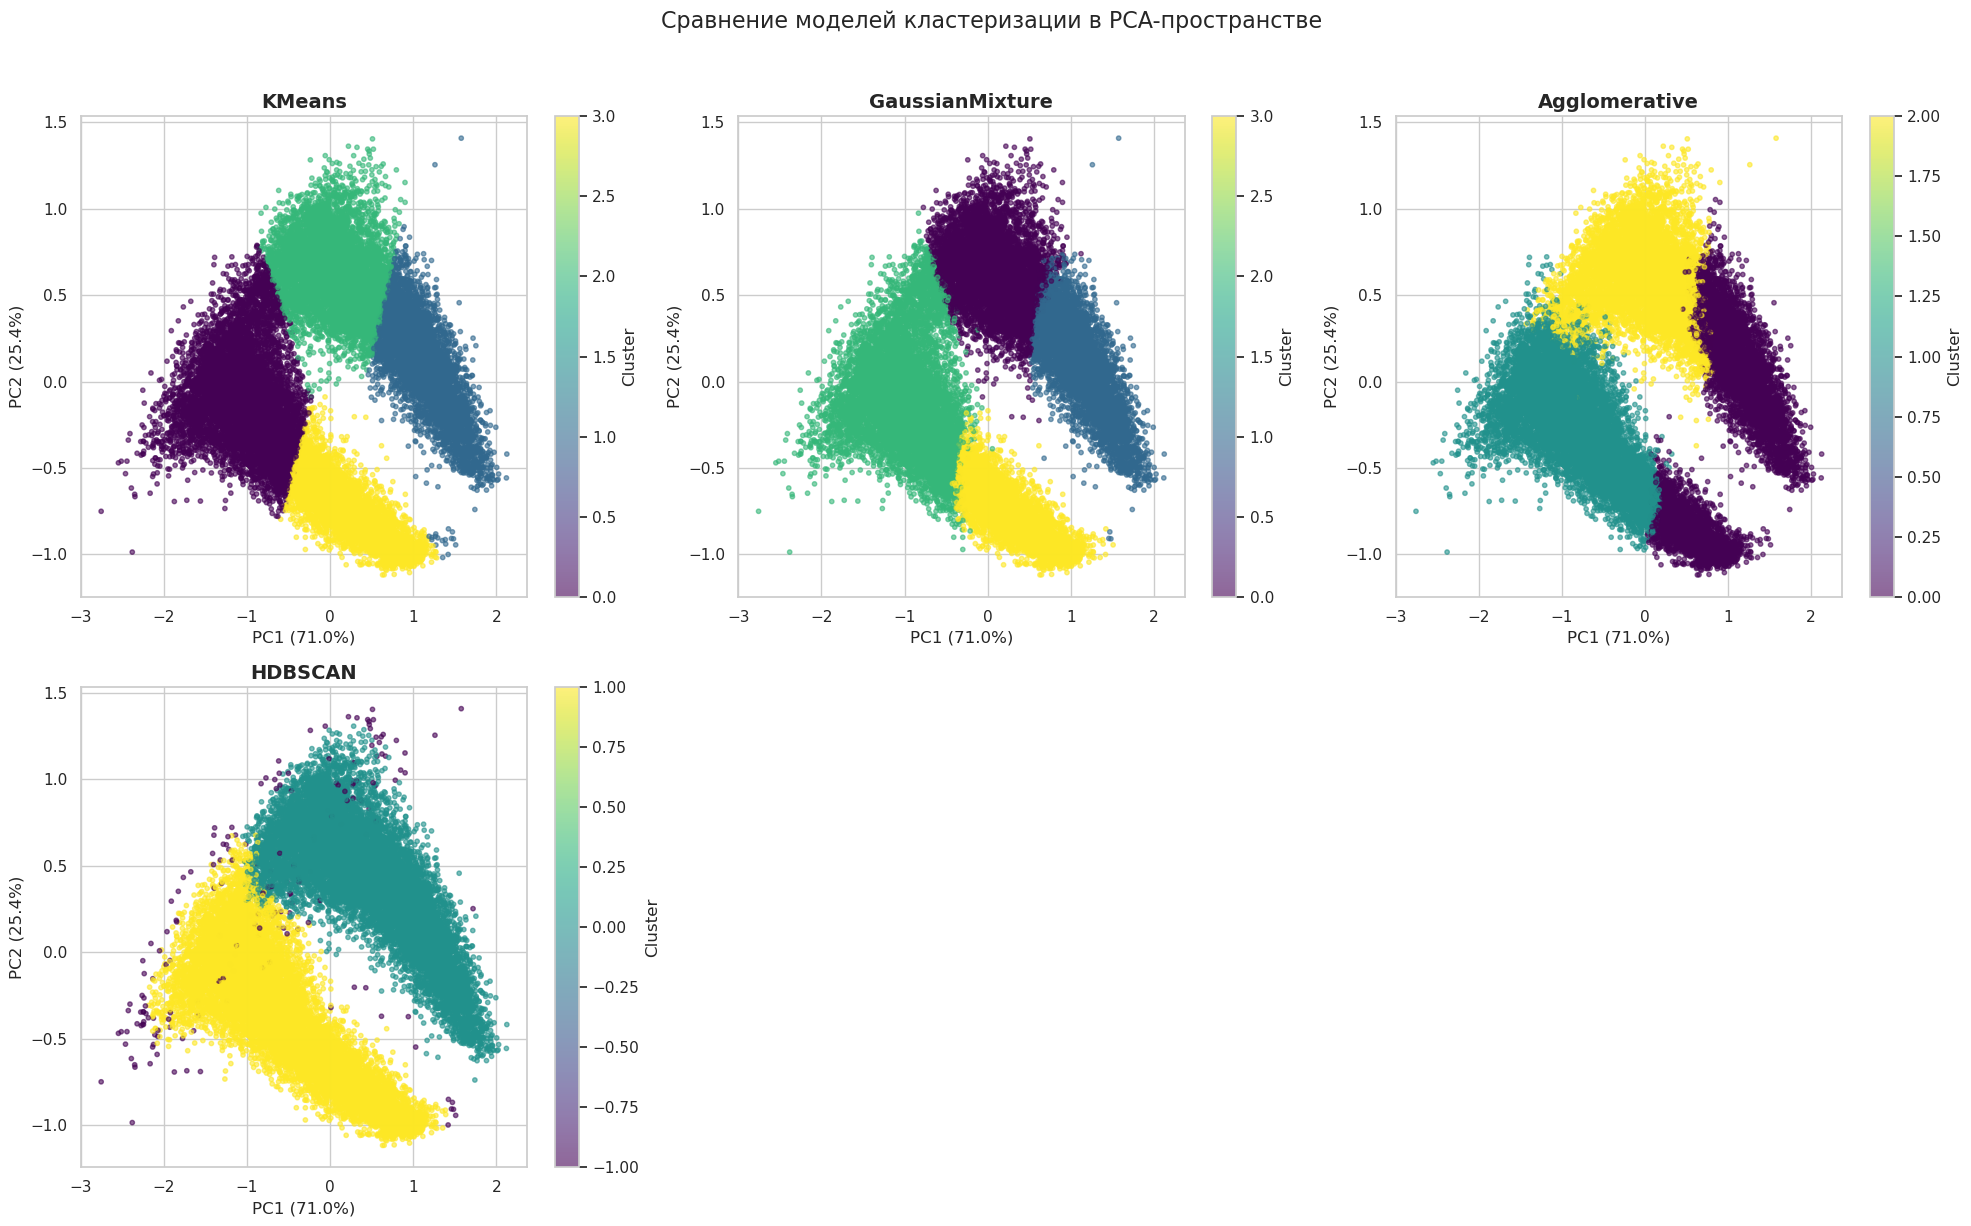

In [43]:
# Сравнение моделей в PCA-пространстве
# 
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, (model_name, model) in enumerate(trained_models.items()):
    if hasattr(model, 'labels_'):
        labels = model.labels_
    elif hasattr(model, 'predict'):
        labels = model.predict(X_scaled)
    else:
        continue
    
    scatter = axes[i].scatter(X_pca[:, 0], X_pca[:, 1], 
                               c=labels, cmap='viridis', 
                               alpha=0.6, s=10)
    axes[i].set_title(f'{model_name}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    axes[i].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    plt.colorbar(scatter, ax=axes[i], label='Cluster')

# Удаляем пустой subplot
axes[-1].axis('off')
axes[-2].axis('off')
plt.suptitle('Сравнение моделей кластеризации в PCA-пространстве', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**Вывод:** Хорошо видно, что лучше всех справилась модель `HDBSCAN`.

## Фиксация лучшей модели

In [44]:
# Получаем лучшую обученную модель HDBSCAN из пайплайна
best_hdbscan = trained_models['HDBSCAN']

# Фильтруем по модели HDBSCAN, выбираем 3 колонки и берем первую строку (.iloc[0]) в виде словаря
best_method = results_df.loc[
    results_df['Model'] == 'HDBSCAN', 
    ['Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin']
].iloc[0].to_dict()
best_method['Model'] = 'HDBSCAN'

# Присваиваем финальные физические метки в исходный df
df_features['Particle_Type'] = best_hdbscan.labels_

# Переименуем для удобства анализа
mapping = {-1: 'Noise', 1: 'Gamma', 0: 'Neutron'}

df_features['Particle_Class'] = df_features['Particle_Type'].map(mapping)

print(df_features['Particle_Class'].value_counts())


Particle_Class
Neutron    11741
Gamma      11555
Noise        183
Name: count, dtype: int64


In [45]:
df_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 23479 entries, 0 to 23478
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Area            23479 non-null  float32
 1   PSD             23479 non-null  float32
 2   Tau             23479 non-null  float32
 3   Particle_Type   23479 non-null  int64  
 4   Particle_Class  23479 non-null  str    
dtypes: float32(3), int64(1), str(1)
memory usage: 642.1 KB


In [46]:
df_features.describe(include='all')

,Area,PSD,Tau,Particle_Type,Particle_Class
count,23479.000000,23479.000000,23479.000000,23479.000000,23479
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,Neutron
freq,NaN,NaN,NaN,NaN,11741
mean,8.419610,0.492627,2.252348,0.484348,NaN
std,1.261473,0.079914,0.667952,0.515126,NaN
min,5.769633,0.178627,0.338969,-1.000000,NaN
25%,7.350490,0.426280,1.703629,0.000000,NaN
50%,8.358507,0.479484,2.231871,0.000000,NaN
75%,9.435120,0.568564,2.767435,1.000000,NaN


В качестве финальной модели выбран `HDBSCAN`, так как он автоматически выделяет кластер шума (cluster -1), что полностью соответствует условию задачи (выделение аномальных сигналов). При этом он показывает высокий показатель Calinski-Harabasz, указывая на хорошую плотность кластеров

## Физическая интерпретация


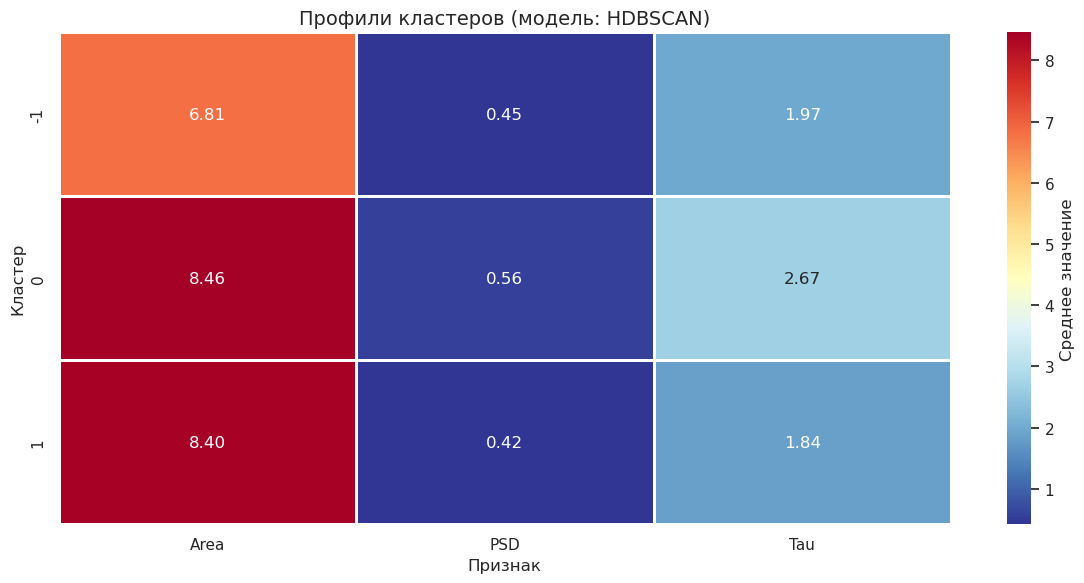


⚛️ ФИЗИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ:

🔸 Кластер -1 (ШУМ/АНОМАЛИИ):
  Размер: 183 (0.8%)
  Средний PSD: 0.4464
  Средняя площадь: 6.81
  Среднее Tau: 2.0
  ❓ Интерпретация: АНОМАЛЬНЫЕ/ПЕРЕХОДНЫЕ сигналы

🔸 Кластер 0:
  Размер: 11741 (50.0%)
  Средний PSD: 0.5647
  Средняя площадь: 8.46
  Среднее Tau: 2.7
  ⚡ Интерпретация: НЕЙТРОНЫ (медленная компонента, пологий хвост)

🔸 Кластер 1:
  Размер: 11555 (49.2%)
  Средний PSD: 0.4201
  Средняя площадь: 8.40
  Среднее Tau: 1.8
  💫 Интерпретация: ГАММА-КВАНТЫ (быстрая компонента, острый пик)


In [47]:
# Анализ центров кластеров лучшей модели 
#
best_model_name = 'HDBSCAN'
best_model = trained_models[best_model_name]

if hasattr(best_model, 'labels_'):
    best_labels = best_model.labels_
else:
    best_labels = best_model.predict(X_scaled)

df_features['cluster'] = best_labels

# Средние значения признаков по кластерам
cluster_profiles = df_features.groupby('cluster')[features_for_clustering].mean()

# Стилизованная тепловая карта
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profiles, annot=True, cmap='RdYlBu_r', fmt='.2f', 
            linewidths=1, cbar_kws={'label': 'Среднее значение'})
plt.title(f'Профили кластеров (модель: {best_model_name})', fontsize=14)
plt.ylabel('Кластер')
plt.xlabel('Признак')
plt.tight_layout()
plt.show()

# Физическая интерпретация
print("\n⚛️ ФИЗИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ:")
print("=" * 70)

for cluster_id in sorted(df_features['cluster'].unique()):
    if cluster_id == -1:
        print(f"\n🔸 Кластер {cluster_id} (ШУМ/АНОМАЛИИ):")
    else:
        print(f"\n🔸 Кластер {cluster_id}:")
    
    subset = df_features[df_features['cluster'] == cluster_id]
    print(f"  Размер: {len(subset)} ({len(subset)/len(df_features):.1%})")
    print(f"  Средний PSD: {subset['PSD'].mean():.4f}")
    print(f"  Средняя площадь: {subset['Area'].mean():.2f}")
    print(f"  Среднее Tau: {subset['Tau'].mean():.1f}")
    
    # Физическая классификация
    psd_mean = subset['PSD'].mean()
    if psd_mean > 0.55:
        print("  ⚡ Интерпретация: НЕЙТРОНЫ (медленная компонента, пологий хвост)")
    elif psd_mean > 0.44:
        print("  ❓ Интерпретация: АНОМАЛЬНЫЕ/ПЕРЕХОДНЫЕ сигналы")
    else:
        print("  💫 Интерпретация: ГАММА-КВАНТЫ (быстрая компонента, острый пик)")
        

**Вывод:** Видно, что для аномалий и шума важную роль сыграла `Area` (площадь сигнала), она гораздо меньше, чем у обычных частиц. Для нейтронов — высокие показатели `PSD` (пологость спуска с пика) и `Tau` (время затухания долгой компоненты свечения).

**Возможные улучшения:**
* Попробовать добавить новый признак двухкомпонентный `Tau`, с учётом времени свечения быстрой компоненты.
* Для большей точности можно попробовать расчитать признак `Tay` через более точную подгонку используя метод `curve_fit` из библиотеки `SciPy`.

## Финальная визуализация

In [56]:
def plot_scintillation_proportional_final(
    dataset,
    df_features,
    cluster_column="Particle_Type",
    time_start=140,
    time_end=187,
    total_sample_size=1000,
    use_log=True,
):
    """Финальная функция визуализации пропорциональной выборки с медианами и
    опциональной логарифмической шкалой.
    """
    colors = {1: "royalblue", 0: "darkorange", -1: "crimson"}
    labels_dict = {
        1: "Гамма-кванты",
        0: "Нейтроны",
        -1: "Аномалии / Шум",
    }

    np.random.seed(RANDOM_STATE)
    selected_indices = np.random.choice(
        df_features.index,
        size=min(total_sample_size, len(df_features)),
        replace=False,
    )

    time_range = range(time_start, time_end)
    signals_by_cluster = {0: [], 1: [], 2: []}

    fig, ax = plt.subplots(figsize=(16, 8))
    added_labels = set()

    for idx in selected_indices:
        cluster_id = df_features.loc[idx, cluster_column]
        signal = (2**14 - dataset.iloc[idx] - 1560).values
        signal_slice = signal[time_start:time_end]

        if cluster_id in signals_by_cluster:
            signals_by_cluster[cluster_id].append(signal_slice)

        if cluster_id not in added_labels:
            ax.plot(
                time_range,
                signal_slice,
                color=colors[cluster_id],
                alpha=0.3,
                linewidth=0.8,
                label=labels_dict[cluster_id],
            )
            added_labels.add(cluster_id)
        else:
            ax.plot(
                time_range,
                signal_slice,
                color=colors[cluster_id],
                alpha=0.15,
                linewidth=0.6,
                label="",
            )

    # Отрисовка медиан
    for cluster_id in sorted(signals_by_cluster.keys()):
        cluster_signals = signals_by_cluster[cluster_id]
        if len(cluster_signals) > 0:
            median_profile = np.median(cluster_signals, axis=0)
            # Защита от нулевых/отрицательных значений в log шкале
            if use_log:
                median_profile = np.clip(median_profile, 0.1, None)

            ax.plot(
                time_range,
                median_profile,
                color=colors[cluster_id],
                linewidth=4.0,
                alpha=1.0,
                zorder=10,
            )
            ax.plot(
                time_range,
                median_profile,
                color="black",
                linewidth=5.5,
                alpha=0.25,
                zorder=9,
            )

    ax.set_title(
        f"Пропорциональное разделение и медианные тренды затухания (Срез: {time_start} - {time_end} нс)",
        fontsize=14,
        pad=15,
    )
    ax.set_xlabel("time, ns", fontsize=12)
    ax.set_ylabel("bit ADC", fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.3)

    if use_log:
        ax.set_yscale("log")

    legend = ax.legend(loc="upper right", fontsize=11)
    if legend:
        for line in legend.get_lines():
            line.set_linewidth(3.5)
            line.set_alpha(1.0)

    plt.tight_layout()
    plt.show()


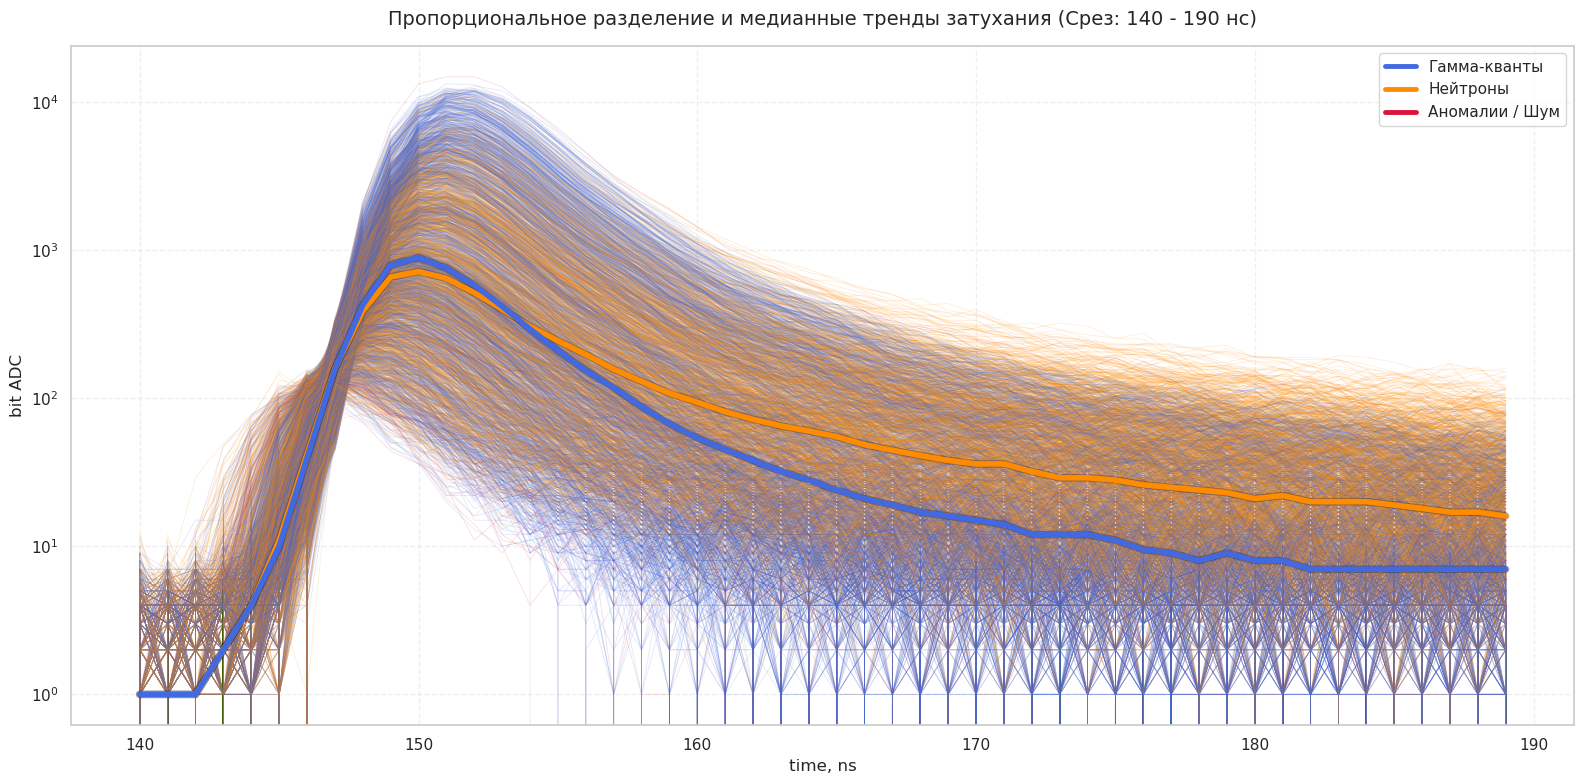

In [57]:
plot_scintillation_proportional_final(
    dataset=dataset,
    df_features=df_features,
    cluster_column="Particle_Type",
    time_start=140,
    time_end=190,
    total_sample_size=3333,  # берем большую выборку для точной статистики
    use_log=True,
)


**Вывод:** Видно, что медианные значения практически сливаются в начале. Пик, похоже, что у гамма-квантов больше, но потом нейтроны дольше светятся.

# 5. Kaggle submission

https://www.kaggle.com/competitions/scintillation-detector/

In [58]:
# Создаем DataFrame для submission
submission = pd.DataFrame({
    'index': df_features.index,
    'cluster': best_labels
})
submission.head()

,index,cluster
0,0,0
1,1,1
2,2,1
3,3,0
4,4,1


In [51]:
unique_labels = submission['cluster'].unique()
unique_labels

array([ 0,  1, -1])

In [52]:
# Создаем маппинг автоматически: значение -> порядковый номер (начиная с 0)
mapping = {val: i + 0 for i, val in enumerate(unique_labels)}

# Применяем маппинг
submission['cluster'] = submission['cluster'].map(mapping)

submission['cluster'].value_counts()

cluster
0    11741
1    11555
2      183
Name: count, dtype: int64

In [53]:
submission.head()

,index,cluster
0,0,0
1,1,1
2,2,1
3,3,0
4,4,1


In [54]:
# Проверяем формат
print("\nПервые 5 строк submission:")
print(submission.head(5))
print(f"\nРазмер submission: {submission.shape}")
print(f"Колонки: {submission.columns.tolist()}")

# Сохраняем в CSV файл
submission_filename = path + "/" + 'submission_HDBSCAN.csv'
submission.to_csv(submission_filename, index=False)
print(f"\nФайл сохранен: {submission_filename}")

# Выводим информацию для загрузки на Kaggle
print("\n" + "="*60)
print("ЗАГРУЗКА НА KAGGLE")
print("="*60)
print(f"1. Файл для загрузки: {submission_filename}")
print(f"2. Формат: index,cluster")
print(f"3. Количество записей: {len(submission)}")
print(f"4. Метод: {best_method['Model']}")
print(f"5. Calinski-Harabasz Score: {best_method['Calinski-Harabasz']:.2f}")
print(f"6. Silhouette Score: {best_method['Silhouette']:.4f}")
print("="*60)


Первые 5 строк submission:
   index  cluster
0      0        0
1      1        1
2      2        1
3      3        0
4      4        1

Размер submission: (23479, 2)
Колонки: ['index', 'cluster']

Файл сохранен: /home/itj/.cache/kagglehub/competitions/scintillation-detector/submission_HDBSCAN.csv

ЗАГРУЗКА НА KAGGLE
1. Файл для загрузки: /home/itj/.cache/kagglehub/competitions/scintillation-detector/submission_HDBSCAN.csv
2. Формат: index,cluster
3. Количество записей: 23479
4. Метод: HDBSCAN
5. Calinski-Harabasz Score: 14703.56
6. Silhouette Score: 0.3870


![Kaggle submit](scintilation-detector-Kaggle_submit.png)